# Telecom Customer Churn Prediction
### Logistic Regression | Random Forest

**Dataset:** `churn-bigml-80.csv` (train, 2,666 rows) + `churn-bigml-20.csv` (test, 667 rows) — BigML Telecom dataset (Kaggle, 3,333 customers, 20 features)  
**Target:** `Churn` — will a customer cancel their subscription? (`True` / `False`)

---

### Project Goal
Build and compare two machine learning models to identify customers likely to churn,
so the business can intervene proactively with retention offers.

---

### Table of Contents

| # | Section | Click to jump |
|:--|:--------|:--------------|
| **1** | **Imports** | [Go to Section 1](#sec-1) |
| **2** | **Load Data** | [Go to Section 2](#sec-2) |
| **3** | **Data Inspection** | [Go to Section 3](#sec-3) |
|   | 3a · Churn by Categorical Features | [Go to 3a](#sec-3a) |
|   | 3b · Churn by Customer Service Calls | [Go to 3b](#sec-3b) |
|   | 3c · Numerical Distributions | [Go to 3c](#sec-3c) |
|   | 3d · Box Plots | [Go to 3d](#sec-3d) |
|   | 3e · Mean Feature Table | [Go to 3e](#sec-3e) |
| **4** | **Preprocessing & Feature Engineering** | [Go to Section 4](#sec-4) |
| **5** | **Logistic Regression — Training** | [Go to Section 5](#sec-5) |
| **6** | **Logistic Regression — Evaluation** | [Go to Section 6](#sec-6) |
| **7** | **Logistic Regression — Visualisations** | [Go to Section 7](#sec-7) |
| **8** | **Logistic Regression — Performance Checks** | [Go to Section 8](#sec-8) |
|   | 8a · Feature Coefficients | [Go to 8a](#sec-8a) |
|   | 8b · Decision Threshold Tuning | [Go to 8b](#sec-8b) |
|   | 8c · 5-Fold Cross-Validation | [Go to 8c](#sec-8c) |
|   | 8d · Correlation Check | [Go to 8d](#sec-8d) |
| **9** | **Random Forest** | [Go to Section 9](#sec-9) |
|   | 9a · Feature Importance | [Go to 9a](#sec-9a) |
|   | 9b · Decision Threshold Tuning | [Go to 9b](#sec-9b) |
|   | 9c · 5-Fold Cross-Validation | [Go to 9c](#sec-9c) |
|   | 9d · Hyperparameter Tuning (GridSearchCV) | [Go to 9d](#sec-9d) |
|   | Regularization — L1 and L2 | [Go to Regularization](#sec-reg) |
| **10** | **Model Comparison** | [Go to Section 10](#sec-12) |
|   | Summary & Business Recommendations | [Go to Summary](#sec-summary) |
| **11** | **Conclusions** | [Go to Section 11](#sec-13) |

<a id="sec-1"></a>

---

## 1. Imports

All libraries are imported upfront so dependencies are visible at a glance.

| Library | Purpose |
|---|---|
| `pandas` / `numpy` | Data loading and numerical operations |
| `matplotlib` / `seaborn` | Visualisation |
| `sklearn` | Preprocessing, all three models, and evaluation metrics |

In [1]:
from IPython.display import display, Markdown
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    f1_score,
    recall_score,
    precision_score,
)

# ── Global visual theme ────────────────────────────────────────────────────────
C = {
    "no_churn":  "#4A90D9",   # calm blue  — No-Churn bars / histograms
    "churn":     "#E05C5C",   # muted red  — Churn bars / histograms
    "lr":        "#4A90D9",   # blue       — Logistic Regression curves
    "rf":        "#27AE60",   # green      — Random Forest curves
    "highlight": "#E74C3C",   # vivid red  — best-threshold dot
    "neutral":   "#7F8C8D",   # grey       — baseline / reference lines
}

plt.rcParams.update({
    # Canvas
    "figure.facecolor":      "white",
    "axes.facecolor":        "#F7F9FC",
    # Spines
    "axes.spines.top":       False,
    "axes.spines.right":     False,
    "axes.spines.left":      True,
    "axes.spines.bottom":    True,
    "axes.edgecolor":        "#CCCCCC",
    # Grid
    "axes.grid":             True,
    "grid.color":            "white",
    "grid.linewidth":        1.4,
    "grid.alpha":            1.0,
    # Ticks
    "xtick.color":           "#555555",
    "ytick.color":           "#555555",
    "xtick.major.size":      0,
    "ytick.major.size":      0,
    # Labels & title
    "axes.titlesize":        13,
    "axes.titleweight":      "bold",
    "axes.titlepad":         10,
    "axes.labelsize":        11,
    "axes.labelcolor":       "#333333",
    # Legend
    "legend.frameon":        True,
    "legend.framealpha":     0.9,
    "legend.edgecolor":      "#DDDDDD",
    "legend.fontsize":       10,
    # Font
    "font.family":           "sans-serif",
    "text.color":            "#222222",
})

def fmt_cm(cm):
    """Return a label array showing count + row-percentage for confusion matrix heatmaps."""
    annot = np.empty_like(cm, dtype=object)
    for i in range(cm.shape[0]):
        row_total = cm[i].sum()
        for j in range(cm.shape[1]):
            pct = cm[i, j] / row_total * 100
            annot[i, j] = f"{cm[i, j]}\n({pct:.0f}%)"
    return annot

print("Libraries loaded successfully.")

Libraries loaded successfully.


<a id="sec-2"></a>

---

## 2. Load Data

The dataset is pre-split into two CSV files:
- **`churn-bigml-80.csv`** — 80% of the data, used for **training**
- **`churn-bigml-20.csv`** — 20% of the data, used for **testing**

We load both files and combine them into a single DataFrame (`df`) for exploratory data analysis, then use the original split for modelling.

In [2]:
df_train_raw = pd.read_csv("/Users/patrick/Desktop/Machine project/churn-bigml-80.csv")
df_test_raw  = pd.read_csv("/Users/patrick/Desktop/Machine project/churn-bigml-20.csv")

# Combine for exploratory data analysis (Sections 3a–3e)
df = pd.concat([df_train_raw, df_test_raw], ignore_index=True)

print(f"Training set (80%): {df_train_raw.shape[0]:,} rows")
print(f"Test set     (20%): {df_test_raw.shape[0]:,} rows")
print(f"Combined          : {df.shape[0]:,} rows, {df.shape[1]} columns")

Training set (80%): 2,666 rows
Test set     (20%): 667 rows
Combined          : 3,333 rows, 20 columns


<a id="sec-3"></a>

---

## 3. Data Inspection

Before touching anything, we examine the raw data systematically — both numerically and visually.

| Sub-section | What it shows |
|---|---|
| Basic checks | Shape, dtypes, missing values, class balance |
| **3a** | Churn rate by categorical plan features |
| **3b** | Churn rate escalation by customer service call count (table + bar chart) |
| **3c** | Overlapping distributions of key features — churners vs non-churners |
| **3d** | Box plots: median, IQR, and outliers by churn class |
| **3e** | Mean feature comparison table sorted by % difference |

In [3]:
# First 5 rows — get a feel for the data
df.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [4]:
# Column types and non-null counts
# 3 string columns (State, International plan, Voice mail plan) need encoding
# 1 bool column (Churn) is the target
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   3333 non-null   str    
 1   Account length          3333 non-null   int64  
 2   Area code               3333 non-null   int64  
 3   International plan      3333 non-null   str    
 4   Voice mail plan         3333 non-null   str    
 5   Number vmail messages   3333 non-null   int64  
 6   Total day minutes       3333 non-null   float64
 7   Total day calls         3333 non-null   int64  
 8   Total day charge        3333 non-null   float64
 9   Total eve minutes       3333 non-null   float64
 10  Total eve calls         3333 non-null   int64  
 11  Total eve charge        3333 non-null   float64
 12  Total night minutes     3333 non-null   float64
 13  Total night calls       3333 non-null   int64  
 14  Total night charge      3333 non-null   float64
 15

In [5]:
# Summary statistics — check for unusual ranges or outliers
df.describe()

,Account length,Area code,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls
count,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000
mean,101.064806,437.182418,8.099010,179.775098,100.435644,30.562307,200.980348,100.114311,17.083540,200.872037,100.107711,9.039325,10.237294,4.479448,2.764581,1.562856
std,39.822106,42.371290,13.688365,54.467389,20.069084,9.259435,50.713844,19.922625,4.310668,50.573847,19.568609,2.275873,2.791840,2.461214,0.753773,1.315491
min,1.000000,408.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,23.200000,33.000000,1.040000,0.000000,0.000000,0.000000,0.000000
25%,74.000000,408.000000,0.000000,143.700000,87.000000,24.430000,166.600000,87.000000,14.160000,167.000000,87.000000,7.520000,8.500000,3.000000,2.300000,1.000000
50%,101.000000,415.000000,0.000000,179.400000,101.000000,30.500000,201.400000,100.000000,17.120000,201.200000,100.000000,9.050000,10.300000,4.000000,2.780000,1.000000
75%,127.000000,510.000000,20.000000,216.400000,114.000000,36.790000,235.300000,114.000000,20.000000,235.300000,113.000000,10.590000,12.100000,6.000000,3.270000,2.000000
max,243.000000,510.000000,51.000000,350.800000,165.000000,59.640000,363.700000,170.000000,30.910000,395.000000,175.000000,17.770000,20.000000,20.000000,5.400000,9.000000


In [6]:
# Missing values per column
print(df.isnull().sum())

State                     0
Account length            0
Area code                 0
International plan        0
Voice mail plan           0
Number vmail messages     0
Total day minutes         0
Total day calls           0
Total day charge          0
Total eve minutes         0
Total eve calls           0
Total eve charge          0
Total night minutes       0
Total night calls         0
Total night charge        0
Total intl minutes        0
Total intl calls          0
Total intl charge         0
Customer service calls    0
Churn                     0
dtype: int64


In [7]:
# Target class distribution
# KEY FINDING: dataset is imbalanced — 86% no churn, 14% churn
# A naive model that always predicts 'no churn' scores 85.51% accuracy
# without learning anything. We must use recall and ROC-AUC to measure real performance.
print(df["Churn"].value_counts())
print()
print(df["Churn"].value_counts(normalize=True).mul(100).round(2).astype(str) + "%")

Churn
False    2850
True      483
Name: count, dtype: int64

Churn
False    85.51%
True     14.49%
Name: proportion, dtype: str


<a id="sec-3a"></a>

---

### 3a. Churn Rate by Categorical Features

Two binary plan features — `International plan` and `Voice mail plan` — are compared  
against churn rate. The dashed line marks the overall churn rate (~14.5%) as a baseline.  
Bars above the line (red) indicate groups that churn at above-average rates.

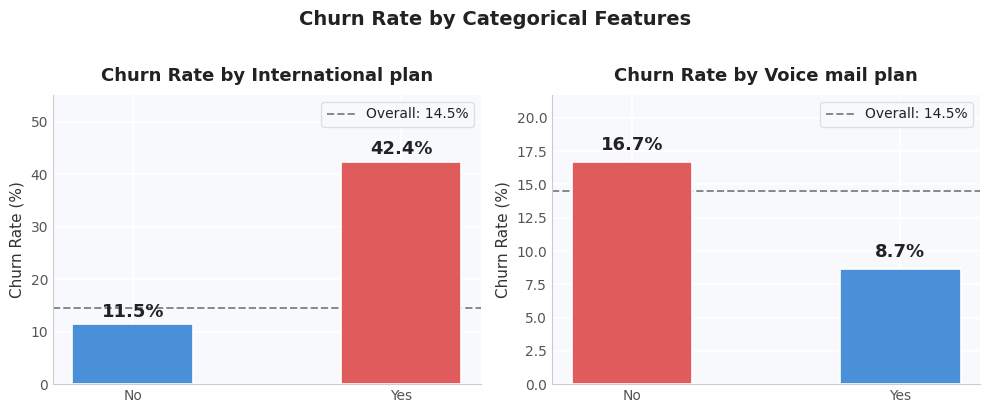

Plot saved -> Desktop/eda_categorical.png


In [8]:
overall_rate = df["Churn"].mean() * 100   # 14.49% — used as reference line

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, col in zip(axes, ["International plan", "Voice mail plan"]):
    churn_rate = (
        df.groupby(col)["Churn"]
        .apply(lambda x: x.mean() * 100)
        .reset_index()
    )
    churn_rate.columns = [col, "Churn Rate (%)"]

    bar_colors = [C["churn"] if v > overall_rate else C["no_churn"]
                  for v in churn_rate["Churn Rate (%)"]]
    bars = ax.bar(churn_rate[col], churn_rate["Churn Rate (%)"],
                  color=bar_colors, edgecolor="white", width=0.45,
                  linewidth=1.2, zorder=3)

    for bar, val in zip(bars, churn_rate["Churn Rate (%)"]):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.6,
                f"{val:.1f}%", ha="center", va="bottom",
                fontsize=13, fontweight="bold", color="#222222")

    ax.axhline(overall_rate, color=C["neutral"], linestyle="--", linewidth=1.4,
               label=f"Overall: {overall_rate:.1f}%", zorder=2)
    ax.set_title(f"Churn Rate by {col}")
    ax.set_ylabel("Churn Rate (%)")
    ax.set_ylim(0, max(churn_rate["Churn Rate (%)"]) * 1.3)
    ax.tick_params(length=0)
    ax.legend()

plt.suptitle("Churn Rate by Categorical Features", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()
print("Plot saved -> Desktop/eda_categorical.png")

<a id="sec-3b"></a>

---

### 3b. Churn Rate by Customer Service Calls

The number of times a customer contacted support is the strongest single predictor in  
the dataset. This chart reveals a dramatic **non-linear escalation**: churn is rare among  
customers who never call, but becomes nearly certain for those who call 5 or more times.

> This non-linearity is one reason tree-based models outperform Logistic Regression —  
> they can capture the sharp step-change around 4+ calls that a linear model can only approximate.

Churn Rate by Number of Customer Service Calls
----------------------------------------------------
 Calls   Customers   Churned   Churn Rate
----------------------------------------------------
     0         697        92        13.2%
     1        1181       122        10.3%
     2         759        87        11.5%
     3         429        44        10.3%
     4         166        76        45.8%
     5          66        40        60.6%
     6          22        14        63.6%
     7           9         5        55.6%
     8           2         1        50.0%
     9           2         2       100.0%


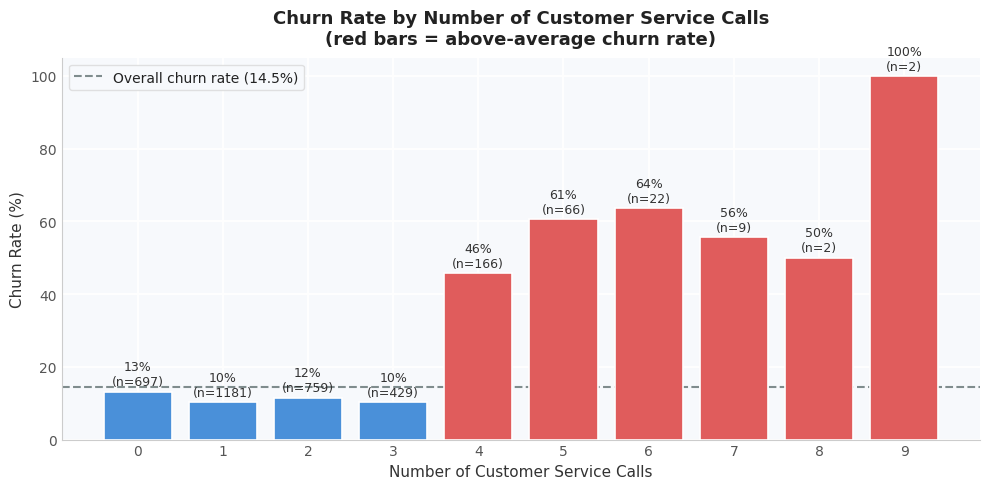

Plot saved -> Desktop/eda_service_calls.png


In [9]:
call_churn = (
    df.groupby("Customer service calls")["Churn"]
    .agg(["sum", "count"])
    .reset_index()
)
call_churn.columns = ["Calls", "Churned", "Total"]
call_churn["Churn Rate (%)"] = (call_churn["Churned"] / call_churn["Total"] * 100).round(1)

# Print table
print("Churn Rate by Number of Customer Service Calls")
print("-" * 52)
print(f"{'Calls':>6}  {'Customers':>10}  {'Churned':>8}  {'Churn Rate':>11}")
print("-" * 52)
for _, row in call_churn.iterrows():
    print(f"{row['Calls']:>6.0f}  {row['Total']:>10.0f}  {row['Churned']:>8.0f}  {row['Churn Rate (%)']:>10.1f}%")

# Plot
overall_rate = df["Churn"].mean() * 100
bar_colors = [C["churn"] if r > overall_rate else C["no_churn"] for r in call_churn["Churn Rate (%)"]]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(call_churn["Calls"], call_churn["Churn Rate (%)"],
              color=bar_colors, edgecolor="white", linewidth=1.2, zorder=3)

for bar, (_, row) in zip(bars, call_churn.iterrows()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.9,
        f"{row['Churn Rate (%)']:.0f}%\n(n={row['Total']:.0f})",
        ha="center", va="bottom", fontsize=9, color="#333333",
    )

ax.axhline(overall_rate, color=C["neutral"], linestyle="--", linewidth=1.5,
           label=f"Overall churn rate ({overall_rate:.1f}%)", zorder=2)
ax.set_title(
    "Churn Rate by Number of Customer Service Calls\n"
    "(red bars = above-average churn rate)"
)
ax.set_xlabel("Number of Customer Service Calls")
ax.set_ylabel("Churn Rate (%)")
ax.set_xticks(call_churn["Calls"])
ax.tick_params(length=0)
ax.legend()
plt.tight_layout()
plt.show()
print("Plot saved -> Desktop/eda_service_calls.png")

<a id="sec-3c"></a>

---

### 3c. Numerical Feature Distributions by Churn Class

Overlapping histograms for four key numerical features — each split into churners (red) and  
non-churners (blue). Dashed vertical lines mark each group's mean.

- A **clear gap between the dashed lines** signals predictive power  
- **Overlapping distributions** mean the feature struggles to separate the classes alone

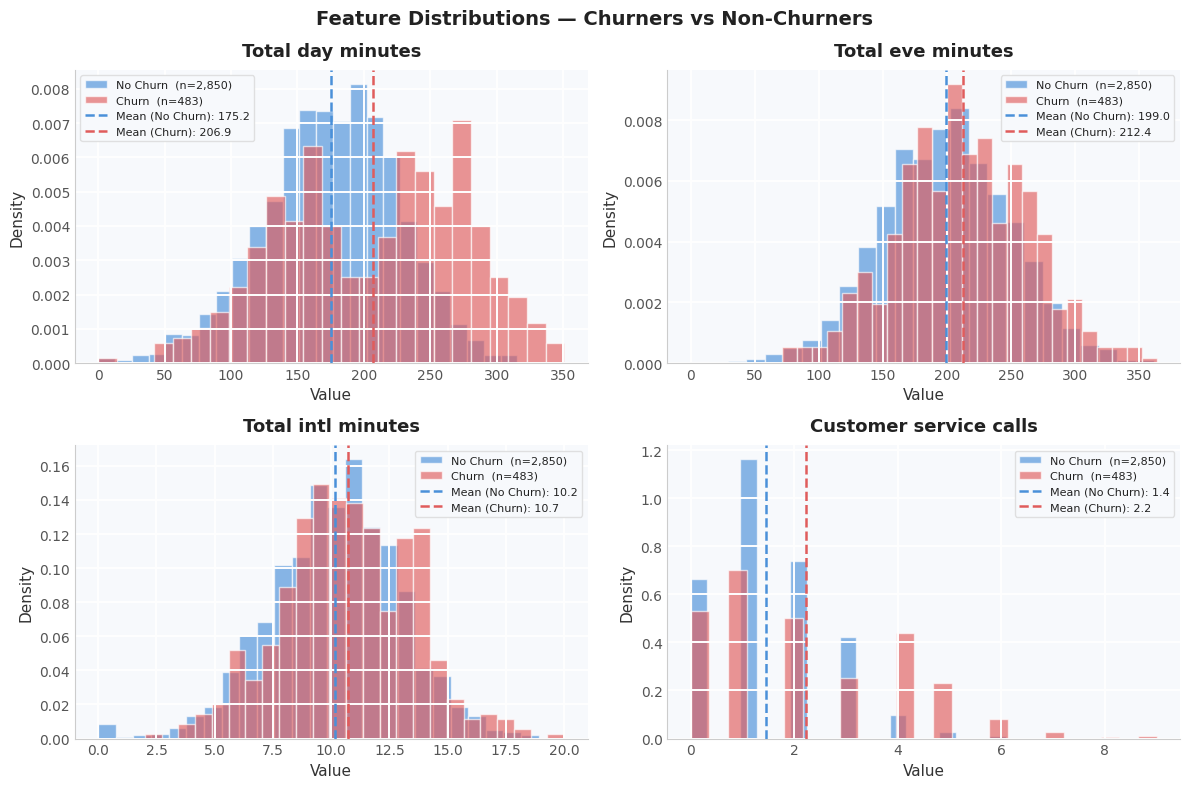

Plot saved -> Desktop/eda_distributions.png


In [10]:
plot_features = [
    "Total day minutes",
    "Total eve minutes",
    "Total intl minutes",
    "Customer service calls",
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, feat in zip(axes, plot_features):
    no_churn = df[df["Churn"] == False][feat]
    churned  = df[df["Churn"] == True][feat]

    ax.hist(no_churn, bins=25, alpha=0.65, color=C["no_churn"],
            label=f"No Churn  (n={len(no_churn):,})", density=True, edgecolor="white")
    ax.hist(churned,  bins=25, alpha=0.65, color=C["churn"],
            label=f"Churn  (n={len(churned):,})",    density=True, edgecolor="white")

    ax.axvline(no_churn.mean(), color=C["no_churn"], linestyle="--", linewidth=1.8,
               label=f"Mean (No Churn): {no_churn.mean():.1f}")
    ax.axvline(churned.mean(),  color=C["churn"],    linestyle="--", linewidth=1.8,
               label=f"Mean (Churn): {churned.mean():.1f}")

    ax.set_title(feat)
    ax.set_xlabel("Value")
    ax.set_ylabel("Density")
    ax.tick_params(length=0)
    ax.legend(fontsize=8)

plt.suptitle("Feature Distributions — Churners vs Non-Churners",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()
print("Plot saved -> Desktop/eda_distributions.png")

<a id="sec-3d"></a>

---

### 3d. Box Plots by Churn Class

Box plots show the **median, interquartile range (IQR), and outliers** for six key features,  
split by churn status.

- Features where the **boxes barely overlap** are strong predictors  
- A higher **median** in the Churn box means churners systematically score higher on that feature  
- Outlier dots reveal extreme individual customers

/var/folders/4s/wz2w369s3zj3pdmj_qwwdws40000gn/T/ipykernel_76139/3637475895.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/4s/wz2w369s3zj3pdmj_qwwdws40000gn/T/ipykernel_76139/3637475895.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/4s/wz2w369s3zj3pdmj_qwwdws40000gn/T/ipykernel_76139/3637475895.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/4s/wz2w369s3zj3pdmj_qwwdws40000gn/T/ipykernel_76139/3637475895.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated a

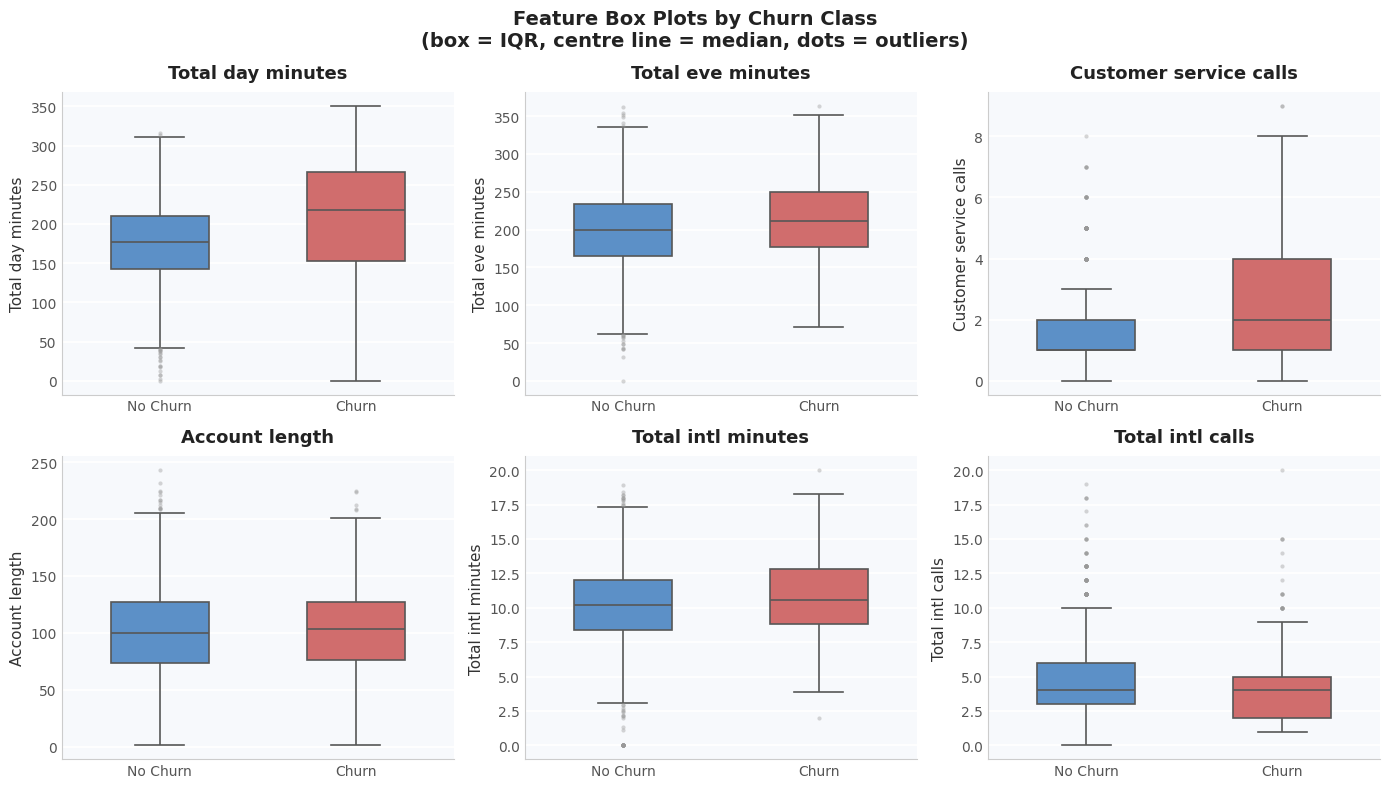

Plot saved -> Desktop/eda_boxplots.png


In [11]:
box_features = [
    "Total day minutes", "Total eve minutes",
    "Customer service calls", "Account length",
    "Total intl minutes", "Total intl calls",
]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for ax, feat in zip(axes, box_features):
    data = df[[feat, "Churn"]].copy()
    data["Churn"] = data["Churn"].map({False: "No Churn", True: "Churn"})
    sns.boxplot(
        x="Churn", y=feat, data=data, ax=ax,
        palette={"No Churn": C["no_churn"], "Churn": C["churn"]},
        order=["No Churn", "Churn"],
        width=0.5,
        linewidth=1.2,
        flierprops=dict(marker="o", markersize=3, alpha=0.4,
                        markerfacecolor="#999999", markeredgewidth=0),
    )
    ax.set_title(feat)
    ax.set_xlabel("")
    ax.tick_params(length=0)

plt.suptitle(
    "Feature Box Plots by Churn Class\n(box = IQR, centre line = median, dots = outliers)",
    fontsize=14, fontweight="bold",
)
plt.tight_layout()
plt.show()
print("Plot saved -> Desktop/eda_boxplots.png")

<a id="sec-3e"></a>

---

### 3e. Mean Feature Values — Churners vs Non-Churners

A clean numerical summary of every group difference, sorted by absolute magnitude.  
The **Diff (%)** column is the most actionable column: it shows how much higher or lower  
the average churner scores on each feature relative to a non-churner.

In [12]:
num_cols = [
    "Account length", "Total day minutes", "Total day calls",
    "Total eve minutes", "Total eve calls", "Total night minutes", "Total night calls",
    "Total intl minutes", "Total intl calls", "Customer service calls",
]

stats = df.groupby("Churn")[num_cols].mean().T
stats.columns = ["No Churn (mean)", "Churn (mean)"]
stats["Diff (%)"] = ((stats["Churn (mean)"] - stats["No Churn (mean)"])
                     / stats["No Churn (mean)"] * 100).round(1)
stats["No Churn (mean)"] = stats["No Churn (mean)"].round(2)
stats["Churn (mean)"]    = stats["Churn (mean)"].round(2)
stats = stats.sort_values("Diff (%)", key=abs, ascending=False)

print("Mean Feature Values — Churners vs Non-Churners")
print("(sorted by absolute % difference)")
print("=" * 62)
print(stats.to_string())
print()
print("Positive Diff (%) → churners average higher than non-churners")
print("Negative Diff (%) → churners average lower than non-churners")

Mean Feature Values — Churners vs Non-Churners
(sorted by absolute % difference)
                        No Churn (mean)  Churn (mean)  Diff (%)
Customer service calls             1.45          2.23      53.8
Total day minutes                175.18        206.91      18.1
Total intl calls                   4.53          4.16      -8.1
Total eve minutes                199.04        212.41       6.7
Total intl minutes                10.16         10.70       5.3
Total night minutes              200.13        205.23       2.5
Account length                   100.79        102.66       1.9
Total day calls                  100.28        101.34       1.0
Total eve calls                  100.04        100.56       0.5
Total night calls                100.06        100.40       0.3

Positive Diff (%) → churners average higher than non-churners
Negative Diff (%) → churners average lower than non-churners


<a id="sec-4"></a>

---

## 4. Preprocessing & Feature Engineering

### Decisions made and why

**Columns dropped:**

| Column | Reason |
|---|---|
| `State` | 51 unique values — too high cardinality |
| `Area code` | Only 3 distinct values, no meaningful signal |
| `Total day/eve/night/intl charge` | Exact linear multiples of the *minutes* columns. Keeping both causes **multicollinearity** |
| `Number vmail messages` | **0.956 correlation** with `Voice mail plan` — nearly identical information |

**Preprocessing Pipeline (ColumnTransformer):**
- **Numeric features** (10) — scaled with `StandardScaler` to zero mean, unit variance
- **Categorical features** (2) — encoded with `OneHotEncoder(drop="first")` to avoid the dummy-variable trap

Both transformations are wrapped inside a `ColumnTransformer`, which is then placed as the first
step of every model `Pipeline`. This ensures the scaler and encoder are **fitted only on training
data** during each call to `.fit()`, preventing data leakage.

**Train/Test Split:** The dataset comes pre-split into two files — `churn-bigml-80.csv` (80% for training) and `churn-bigml-20.csv` (20% for testing). We use these files directly rather than performing a random split, ensuring the intended evaluation protocol is followed.

In [13]:
# 4a. Columns to drop (same rationale for both sets)
drop_cols = [
    "State",
    "Area code",
    "Number vmail messages",   # 0.956 correlation with Voice mail plan
    "Total day charge",        # exact duplicate of Total day minutes x rate
    "Total eve charge",
    "Total night charge",
    "Total intl charge",
]

# 4b. Drop columns from both sets — categorical features stay as raw strings
df_train = df_train_raw.drop(columns=drop_cols).copy()
df_test  = df_test_raw.drop(columns=drop_cols).copy()

# 4c. Convert boolean target to integer (False -> 0, True -> 1)
df_train["Churn"] = df_train["Churn"].astype(int)
df_test["Churn"]  = df_test["Churn"].astype(int)

# 4d. Define feature types — the ColumnTransformer handles encoding + scaling inside the Pipeline
numeric_features = df_train.select_dtypes(include=["int64", "float64"]).drop(columns=["Churn"]).columns.tolist()
categorical_features = df_train.select_dtypes(include=["object"]).columns.tolist()

# 4e. Build the preprocessing pipeline (reused in every model Pipeline)
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features),
    ],
    remainder="drop",
)

print("Columns after dropping:", df_train.columns.tolist())
print(f"Numeric features  ({len(numeric_features)}): {numeric_features}")
print(f"Categorical features ({len(categorical_features)}): {categorical_features}")
df_train.head(3)

Columns after dropping: ['Account length', 'International plan', 'Voice mail plan', 'Total day minutes', 'Total day calls', 'Total eve minutes', 'Total eve calls', 'Total night minutes', 'Total night calls', 'Total intl minutes', 'Total intl calls', 'Customer service calls', 'Churn']
Numeric features  (10): ['Account length', 'Total day minutes', 'Total day calls', 'Total eve minutes', 'Total eve calls', 'Total night minutes', 'Total night calls', 'Total intl minutes', 'Total intl calls', 'Customer service calls']
Categorical features (2): ['International plan', 'Voice mail plan']


/var/folders/4s/wz2w369s3zj3pdmj_qwwdws40000gn/T/ipykernel_76139/300942915.py:22: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = df_train.select_dtypes(include=["object"]).columns.tolist()


,Account length,International plan,Voice mail plan,Total day minutes,Total day calls,Total eve minutes,Total eve calls,Total night minutes,Total night calls,Total intl minutes,Total intl calls,Customer service calls,Churn
0,128,No,Yes,265.1,110,197.4,99,244.7,91,10.0,3,1,0
1,107,No,Yes,161.6,123,195.5,103,254.4,103,13.7,3,1,0
2,137,No,No,243.4,114,121.2,110,162.6,104,12.2,5,0,0


In [14]:
# 4f. Split into features (X) and target (y) — using the pre-split 80/20 CSV files
X_train = df_train.drop(columns=["Churn"])
y_train = df_train["Churn"]
X_test  = df_test.drop(columns=["Churn"])
y_test  = df_test["Churn"]

# Combined X and y — used for cross-validation (Sections 8c, 9c, 10b, 11d)
X = pd.concat([X_train, X_test], ignore_index=True)
y = pd.concat([y_train, y_test], ignore_index=True)

print(f"Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows")
print(f"Train churn rate: {y_train.mean():.2%} | Test churn rate: {y_test.mean():.2%}")
print("Scaling and encoding handled inside Pipeline — no manual scaler needed.")

Train: 2666 rows | Test: 667 rows
Train churn rate: 14.55% | Test churn rate: 14.24%
Scaling and encoding handled inside Pipeline — no manual scaler needed.


<a id="sec-5"></a>

---

## 5. Logistic Regression — Training

**How it works:** Logistic Regression models the log-odds of churn as a linear combination of features,
then converts that to a probability via the sigmoid function.

**Key settings:**
- `class_weight="balanced"` — penalises missing a churner more heavily, compensating for the 86/14 imbalance
- `max_iter=1000` — ensures the solver fully converges

In [15]:
lr_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)),
])
lr_pipeline.fit(X_train, y_train)

lr_pred = lr_pipeline.predict(X_test)
lr_prob = lr_pipeline.predict_proba(X_test)[:, 1]   # probability of churn

print("Logistic Regression trained (Pipeline: ColumnTransformer → LR).")

Logistic Regression trained (Pipeline: ColumnTransformer → LR).


<a id="sec-6"></a>

---

## 6. Logistic Regression — Evaluation

We use several metrics because **accuracy alone is misleading on imbalanced data**.

| Metric | Why it matters here |
|---|---|
| Accuracy | Misleading — always predicting 'no churn' already scores 85.51% |
| **Recall (Churn)** | % of real churners caught — **most business-critical** |
| Precision (Churn) | % of churn predictions that are actually correct |
| F1 (Churn) | Harmonic mean of precision and recall |
| **ROC-AUC** | Ranks churners above non-churners (1.0 = perfect, 0.5 = random) |

In [16]:
# Train predictions (to check for overfitting)
lr_train_pred = lr_pipeline.predict(X_train)
lr_train_prob = lr_pipeline.predict_proba(X_train)[:, 1]

print("=== Train Set ===")
print(f"Accuracy : {accuracy_score(y_train, lr_train_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_train, lr_train_prob):.4f}")
print(f"F1       : {f1_score(y_train, lr_train_pred):.4f}")
print()
print("=== Test Set ===")
print(f"Accuracy : {accuracy_score(y_test, lr_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, lr_prob):.4f}")
print()
print(classification_report(y_test, lr_pred, target_names=["No Churn", "Churn"]))

=== Train Set ===
Accuracy : 0.7697
ROC-AUC  : 0.8234
F1       : 0.4875

=== Test Set ===
Accuracy : 0.7811
ROC-AUC  : 0.8281

              precision    recall  f1-score   support

    No Churn       0.95      0.78      0.86       572
       Churn       0.37      0.76      0.50        95

    accuracy                           0.78       667
   macro avg       0.66      0.77      0.68       667
weighted avg       0.87      0.78      0.81       667



In [17]:
# Confusion matrix — rows = Actual, columns = Predicted
cm_lr = confusion_matrix(y_test, lr_pred)
print("Confusion Matrix:")
print(f"  True  Negatives (correctly said No Churn): {cm_lr[0,0]}")
print(f"  False Positives (wrongly flagged as Churn): {cm_lr[0,1]}")
print(f"  False Negatives (missed actual Churn):      {cm_lr[1,0]}  <- costly")
print(f"  True  Positives (correctly caught Churn):   {cm_lr[1,1]}")

Confusion Matrix:
  True  Negatives (correctly said No Churn): 449
  False Positives (wrongly flagged as Churn): 123
  False Negatives (missed actual Churn):      23  <- costly
  True  Positives (correctly caught Churn):   72


<a id="sec-7"></a>

---

## 7. Logistic Regression — Visualisations

- **Confusion Matrix Heatmap** — four outcome boxes in a colour-coded grid
- **ROC Curve** — True Positive Rate vs False Positive Rate across all thresholds.
  The further the curve bows toward the top-left, the better the model.

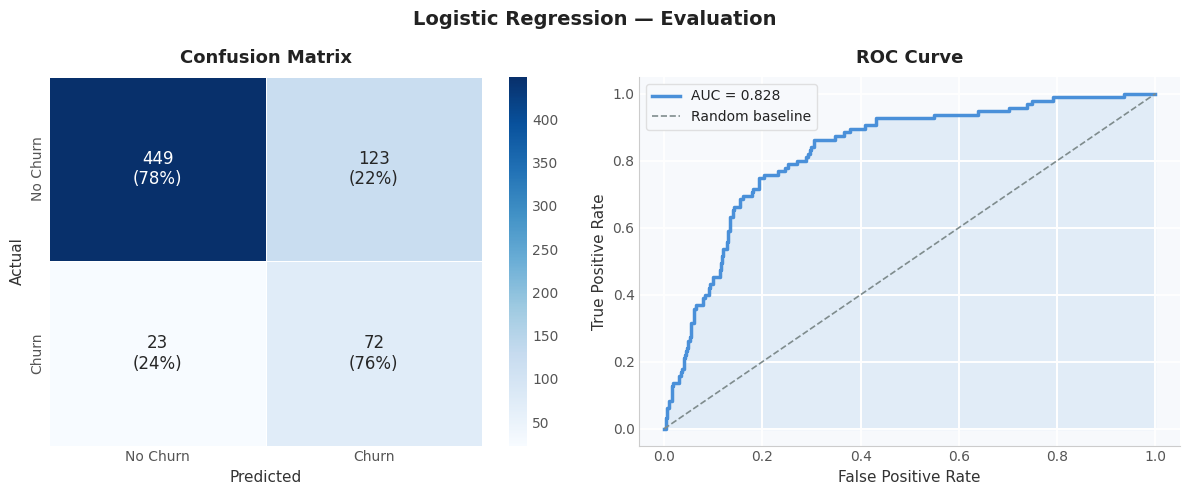

In [18]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_prob)
auc_lr = roc_auc_score(y_test, lr_prob)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ── Confusion Matrix ──────────────────────────────────────────────────────────
sns.heatmap(
    cm_lr, annot=fmt_cm(cm_lr), fmt="", cmap="Blues", ax=axes[0],
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"],
    linewidths=0.5, linecolor="white",
    annot_kws={"size": 12},
)
axes[0].set_title("Confusion Matrix")
axes[0].set_ylabel("Actual")
axes[0].set_xlabel("Predicted")
axes[0].tick_params(length=0)
axes[0].grid(False)

# ── ROC Curve ─────────────────────────────────────────────────────────────────
axes[1].fill_between(fpr_lr, tpr_lr, alpha=0.12, color=C["lr"])
axes[1].plot(fpr_lr, tpr_lr, label=f"AUC = {auc_lr:.3f}",
             color=C["lr"], linewidth=2.5)
axes[1].plot([0, 1], [0, 1], "--", color=C["neutral"], linewidth=1.2,
             label="Random baseline")
axes[1].set_title("ROC Curve")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].tick_params(length=0)
axes[1].legend()

plt.suptitle("Logistic Regression — Evaluation", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

<a id="sec-8"></a>

---

## 8. Logistic Regression — Performance Checks

| Check | Question answered |
|---|---|
| **8a. Feature Coefficients** | Which variables drive churn predictions most strongly? |
| **8b. Threshold Tuning** | Can we catch more churners by adjusting the decision cut-off? |
| **8c. Cross-Validation** | Is performance stable across different data splits? |
| **8d. Correlation Check** | Are any remaining features still redundant? |

<a id="sec-8a"></a>

### 8a. Feature Importance via Coefficients

Each feature has a **coefficient** representing its log-odds contribution to churn.  
- **Positive** → increases churn probability | **Negative** → decreases it  
- **Larger absolute value** → stronger influence  

Because features are scaled, coefficients are directly comparable across columns.

               Feature  Coefficient
International plan_Yes     2.345340
   Voice mail plan_Yes    -0.773794
Customer service calls     0.756503
     Total day minutes     0.666142
     Total eve minutes     0.272458
    Total intl minutes     0.223396
      Total intl calls    -0.206472
   Total night minutes     0.141968
       Total day calls     0.047592
        Account length     0.032152
     Total night calls     0.006965
       Total eve calls     0.005335


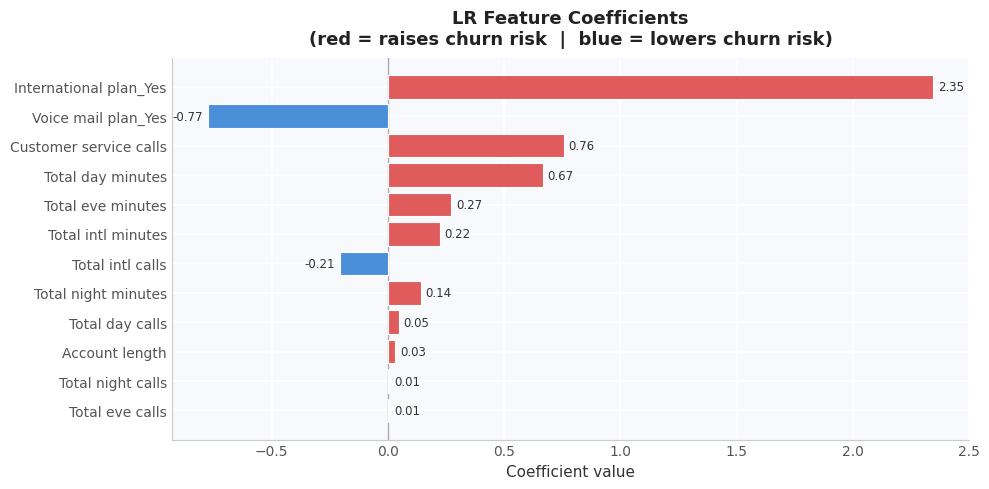

In [19]:
# Extract feature names from the fitted preprocessor
feature_names = preprocessor.get_feature_names_out()
feature_names = [f.split("__", 1)[1] if "__" in f else f for f in feature_names]

coef_df = pd.DataFrame({
    "Feature":     feature_names,
    "Coefficient": lr_pipeline.named_steps["model"].coef_[0],
}).sort_values("Coefficient", key=abs, ascending=True)   # ascending=True → most important at top

print(coef_df.iloc[::-1].to_string(index=False))

bar_colors = [C["churn"] if c > 0 else C["no_churn"] for c in coef_df["Coefficient"]]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(coef_df["Feature"], coef_df["Coefficient"],
               color=bar_colors, edgecolor="white", linewidth=0.8, zorder=3)

# Value labels on each bar
for bar, val in zip(bars, coef_df["Coefficient"]):
    xpos = val + 0.02 if val >= 0 else val - 0.02
    ha   = "left"     if val >= 0 else "right"
    ax.text(xpos, bar.get_y() + bar.get_height() / 2,
            f"{val:.2f}", va="center", ha=ha, fontsize=8.5, color="#333333")

ax.axvline(0, color="#AAAAAA", linewidth=1.0, zorder=2)
ax.set_title(
    "LR Feature Coefficients\n"
    "(red = raises churn risk  |  blue = lowers churn risk)"
)
ax.set_xlabel("Coefficient value")
ax.tick_params(length=0)
plt.tight_layout()
plt.show()

<a id="sec-8b"></a>

### 8b. Decision Threshold Tuning

By default, a probability > **0.5** triggers a churn prediction. For imbalanced classes this is rarely optimal.  
- **Lower threshold** → recall ↑ (catch more churners), precision ↓ (more false alarms)  
- We sweep all thresholds and pick the one that maximises **F1 for the churn class**.

In [20]:
precisions_pr, recalls_pr, thresholds_pr = precision_recall_curve(y_test, lr_prob)

f1_scores_pr   = (2 * precisions_pr[:-1] * recalls_pr[:-1]
                  / (precisions_pr[:-1] + recalls_pr[:-1] + 1e-9))
best_idx       = f1_scores_pr.argmax()
best_threshold = thresholds_pr[best_idx]

lr_pred_tuned  = (lr_prob >= best_threshold).astype(int)

print(f"Default threshold  (0.50) -> Churn F1 = {f1_score(y_test, lr_pred):.3f}")
print(f"Optimised threshold ({best_threshold:.2f}) -> Churn F1 = {f1_score(y_test, lr_pred_tuned):.3f}")
print()
print("Classification Report at optimised threshold:")
print(classification_report(y_test, lr_pred_tuned, target_names=["No Churn", "Churn"]))

Default threshold  (0.50) -> Churn F1 = 0.497
Optimised threshold (0.61) -> Churn F1 = 0.525

Classification Report at optimised threshold:
              precision    recall  f1-score   support

    No Churn       0.94      0.86      0.90       572
       Churn       0.43      0.66      0.53        95

    accuracy                           0.83       667
   macro avg       0.69      0.76      0.71       667
weighted avg       0.87      0.83      0.84       667



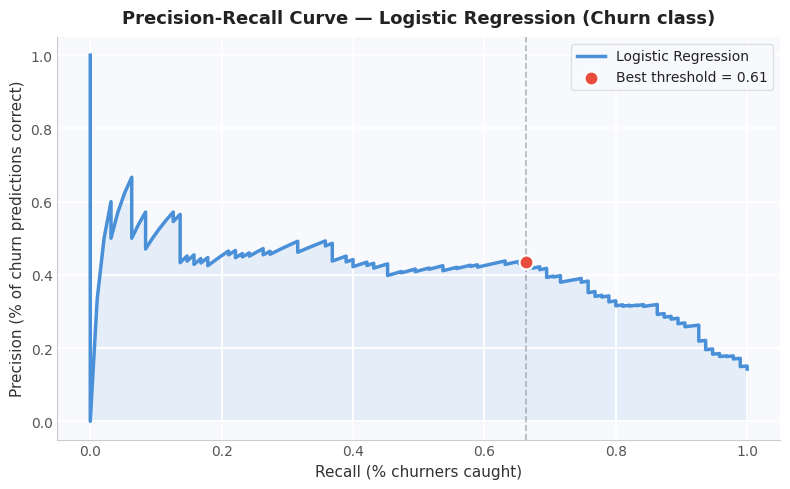

In [21]:
# Precision-Recall curve — the red dot marks the threshold that maximises F1
fig, ax = plt.subplots(figsize=(8, 5))

ax.fill_between(recalls_pr, precisions_pr, alpha=0.10, color=C["lr"])
ax.plot(recalls_pr, precisions_pr, color=C["lr"], linewidth=2.5,
        label="Logistic Regression")
ax.scatter(recalls_pr[best_idx], precisions_pr[best_idx],
           color=C["highlight"], zorder=5, s=100, edgecolors="white", linewidths=1.5,
           label=f"Best threshold = {best_threshold:.2f}")
ax.axvline(recalls_pr[best_idx], color=C["neutral"], linestyle="--",
           linewidth=1.2, alpha=0.6)

ax.set_xlabel("Recall (% churners caught)")
ax.set_ylabel("Precision (% of churn predictions correct)")
ax.set_title("Precision-Recall Curve — Logistic Regression (Churn class)")
ax.tick_params(length=0)
ax.legend()
plt.tight_layout()
plt.show()

<a id="sec-8c"></a>

### 8c. 5-Fold Stratified Cross-Validation

With a fixed train/test CSV split, **cross-validation** trains and tests 5 times on
different folds of the training data and averages the results for a more reliable performance estimate.

We wrap scaler + model in a **Pipeline** so the scaler is re-fitted inside each fold — preventing data leakage.

In [22]:
lr_cv_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)),
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = cross_validate(lr_cv_pipeline, X, y, cv=cv, scoring=["accuracy", "roc_auc", "f1"])

print("Logistic Regression — 5-Fold Cross-Validation")
print("-" * 58)
for metric in ["accuracy", "roc_auc", "f1"]:
    scores = cv_results[f"test_{metric}"]
    print(f"  {metric:10s}: {scores.mean():.4f} +/- {scores.std():.4f}   per fold: {np.round(scores, 3)}")

Logistic Regression — 5-Fold Cross-Validation
----------------------------------------------------------
  accuracy  : 0.7693 +/- 0.0154   per fold: [0.748 0.771 0.793 0.758 0.776]
  roc_auc   : 0.8183 +/- 0.0256   per fold: [0.781 0.813 0.86  0.812 0.825]
  f1        : 0.4852 +/- 0.0280   per fold: [0.455 0.485 0.537 0.469 0.481]


<a id="sec-8d"></a>

### 8d. Remaining Feature Correlation Check

After preprocessing we verify no high correlations remain.  
**Rule of thumb:** |correlation| > 0.7 between two features is worth investigating.

Feature pairs with |correlation| > 0.70:
  None found — all pairwise correlations are below 0.70 ✓


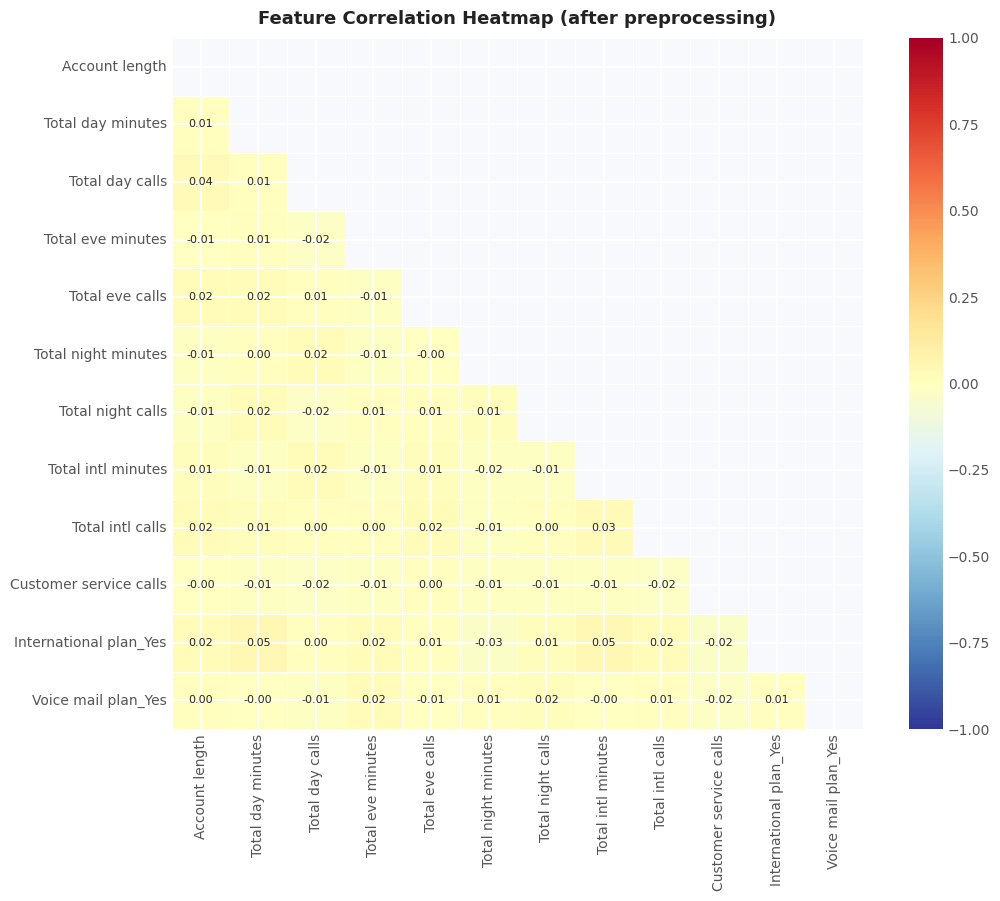

In [23]:
# Transform the combined dataset through the preprocessor for correlation analysis
# (needed because X now contains raw string columns that can't correlate directly)
X_transformed = pd.DataFrame(
    preprocessor.fit_transform(X),
    columns=[f.split("__", 1)[1] if "__" in f else f for f in preprocessor.get_feature_names_out()],
)

corr = X_transformed.corr()
high_corr_mask = (corr.abs() > 0.7) & (corr.abs() < 1.0)

print("Feature pairs with |correlation| > 0.70:")
if high_corr_mask.any().any():
    pairs = (corr.where(high_corr_mask)
                 .stack(dropna=True)
                 .reset_index()
                 .rename(columns={"level_0": "Feature A", "level_1": "Feature B", 0: "Correlation"}))
    pairs = pairs[pairs["Feature A"] < pairs["Feature B"]]
    print(pairs.to_string(index=False))
else:
    print("  None found — all pairwise correlations are below 0.70 ✓")

# Show only the lower triangle (cleaner, no redundancy)
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    corr, mask=mask,
    annot=True, fmt=".2f",
    cmap="RdYlBu_r", center=0,
    linewidths=0.4, linecolor="white",
    square=True, ax=ax,
    annot_kws={"size": 8},
    vmin=-1, vmax=1,
)
ax.set_title("Feature Correlation Heatmap (after preprocessing)")
ax.tick_params(length=0)
plt.tight_layout()
plt.show()

<a id="sec-9"></a>

---

## 9. Random Forest

**How it works:** A Random Forest builds many decision trees, each trained on a random
bootstrap sample of the data and a random subset of features. The final prediction is
the majority vote across all trees.

**Why it often outperforms Logistic Regression:**
- Captures **non-linear relationships** and **feature interactions** that a linear model cannot
- More robust to outliers — splits are based on ordering, not magnitude
- Provides its own **feature importance** ranking via mean decrease in impurity

**Key hyperparameters:**

| Parameter | Value | Reason |
|---|---|---|
| `n_estimators` | 100 | 100 trees — good balance of stability and speed |
| `class_weight` | `balanced` | Same imbalance correction as logistic regression |
| `random_state` | 42 | Reproducibility |

> Random Forest is **tree-based** — it splits on feature value thresholds, not distances.
> Feature scaling is **not needed**.

In [24]:
rf_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42)),
])
rf_pipeline.fit(X_train, y_train)

rf_pred = rf_pipeline.predict(X_test)
rf_prob = rf_pipeline.predict_proba(X_test)[:, 1]

print("Random Forest trained (Pipeline: ColumnTransformer → RF).")

Random Forest trained (Pipeline: ColumnTransformer → RF).


In [25]:
# Train predictions (to check for overfitting)
rf_train_pred = rf_pipeline.predict(X_train)
rf_train_prob = rf_pipeline.predict_proba(X_train)[:, 1]

print("=== Train Set ===")
print(f"Accuracy : {accuracy_score(y_train, rf_train_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_train, rf_train_prob):.4f}")
print(f"F1       : {f1_score(y_train, rf_train_pred):.4f}")
print()
print("=== Test Set ===")
print(f"Accuracy : {accuracy_score(y_test, rf_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, rf_prob):.4f}")
print()
print(classification_report(y_test, rf_pred, target_names=["No Churn", "Churn"]))

=== Train Set ===
Accuracy : 0.9992
ROC-AUC  : 1.0000
F1       : 0.9974

=== Test Set ===
Accuracy : 0.9490
ROC-AUC  : 0.9225

              precision    recall  f1-score   support

    No Churn       0.95      1.00      0.97       572
       Churn       0.98      0.65      0.78        95

    accuracy                           0.95       667
   macro avg       0.96      0.83      0.88       667
weighted avg       0.95      0.95      0.94       667



In [26]:
cm_rf = confusion_matrix(y_test, rf_pred)
print("Confusion Matrix:")
print(f"  True  Negatives (correctly said No Churn): {cm_rf[0,0]}")
print(f"  False Positives (wrongly flagged as Churn): {cm_rf[0,1]}")
print(f"  False Negatives (missed actual Churn):      {cm_rf[1,0]}  <- costly")
print(f"  True  Positives (correctly caught Churn):   {cm_rf[1,1]}")

Confusion Matrix:
  True  Negatives (correctly said No Churn): 571
  False Positives (wrongly flagged as Churn): 1
  False Negatives (missed actual Churn):      33  <- costly
  True  Positives (correctly caught Churn):   62


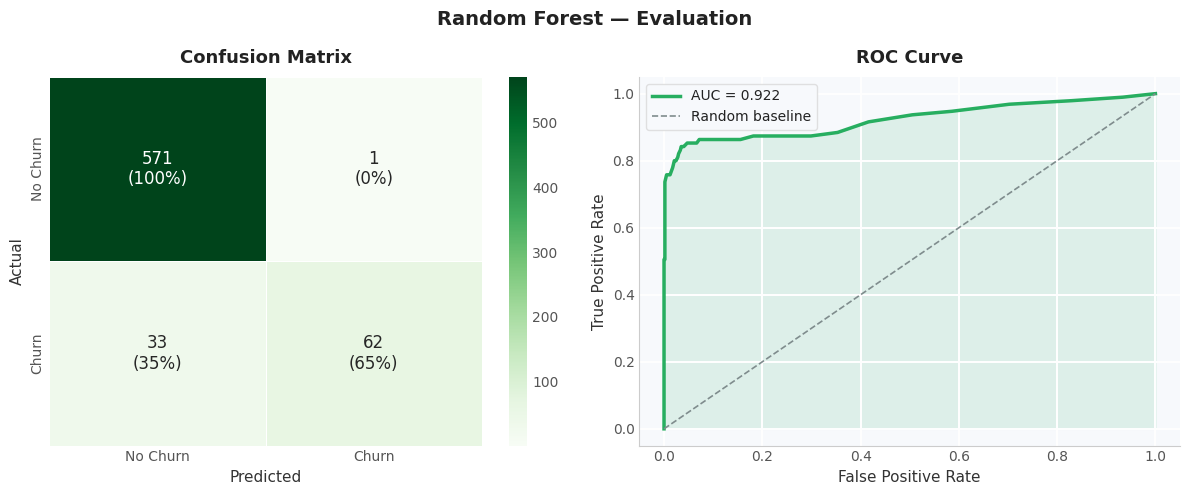

In [27]:
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)
auc_rf = roc_auc_score(y_test, rf_prob)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ── Confusion Matrix ──────────────────────────────────────────────────────────
sns.heatmap(
    cm_rf, annot=fmt_cm(cm_rf), fmt="", cmap="Greens", ax=axes[0],
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"],
    linewidths=0.5, linecolor="white",
    annot_kws={"size": 12},
)
axes[0].set_title("Confusion Matrix")
axes[0].set_ylabel("Actual")
axes[0].set_xlabel("Predicted")
axes[0].tick_params(length=0)
axes[0].grid(False)

# ── ROC Curve ─────────────────────────────────────────────────────────────────
axes[1].fill_between(fpr_rf, tpr_rf, alpha=0.12, color=C["rf"])
axes[1].plot(fpr_rf, tpr_rf, label=f"AUC = {auc_rf:.3f}",
             color=C["rf"], linewidth=2.5)
axes[1].plot([0, 1], [0, 1], "--", color=C["neutral"], linewidth=1.2,
             label="Random baseline")
axes[1].set_title("ROC Curve")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].tick_params(length=0)
axes[1].legend()

plt.suptitle("Random Forest — Evaluation", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

<a id="sec-9a"></a>

### 9a. Random Forest Feature Importance

Random Forest provides a different type of importance than logistic regression coefficients.

- **Mean Decrease in Impurity (MDI):** how much each feature reduces uncertainty (Gini impurity)
  across all splits in all trees
- Values are **always positive** and sum to 1
- Compare with the LR coefficients from Section 8a to see if both models agree on top predictors

               Feature  Importance
     Total day minutes    0.231968
Customer service calls    0.153161
International plan_Yes    0.100625
     Total eve minutes    0.092037
    Total intl minutes    0.074463
   Total night minutes    0.068146
       Total day calls    0.052077
        Account length    0.050809
       Total eve calls    0.049691
      Total intl calls    0.049611
     Total night calls    0.048606
   Voice mail plan_Yes    0.028805


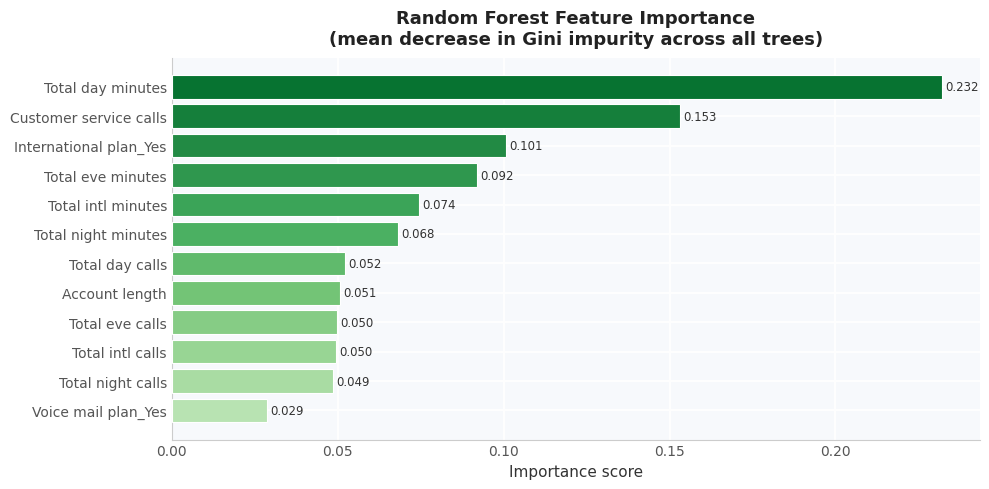

In [28]:
# Extract feature names from the fitted preprocessor
feature_names = preprocessor.get_feature_names_out()
feature_names = [f.split("__", 1)[1] if "__" in f else f for f in feature_names]

rf_imp = pd.DataFrame({
    "Feature":    feature_names,
    "Importance": rf_pipeline.named_steps["model"].feature_importances_,
}).sort_values("Importance", ascending=True)   # ascending so most important is at top of barh

print(rf_imp.iloc[::-1].to_string(index=False))

# Gradient colour: darker green = more important
n = len(rf_imp)
greens = plt.cm.Greens(np.linspace(0.3, 0.85, n))

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(rf_imp["Feature"], rf_imp["Importance"],
               color=greens, edgecolor="white", linewidth=0.8, zorder=3)

for bar, val in zip(bars, rf_imp["Importance"]):
    ax.text(val + 0.001, bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}", va="center", fontsize=8.5, color="#333333")

ax.set_title(
    "Random Forest Feature Importance\n"
    "(mean decrease in Gini impurity across all trees)"
)
ax.set_xlabel("Importance score")
ax.tick_params(length=0)
plt.tight_layout()
plt.show()

<a id="sec-9b"></a>

---

### 9b. Random Forest — Decision Threshold Tuning

Random Forest achieves the best ROC-AUC of all models (0.922) but only catches **57.9% of churners** at the
default 0.5 threshold — missing more than four in ten. Applying the same precision-recall sweep
as Section 8b can dramatically improve recall while preserving the high AUC advantage.

- **Lower threshold** → more customers flagged as churn → recall ↑, precision ↓  
- We pick the threshold that maximises **F1 (Churn)** as the best overall trade-off.

In [29]:
precisions_rf_pr, recalls_rf_pr, thresholds_rf_pr = precision_recall_curve(y_test, rf_prob)

f1_scores_rf_pr = (2 * precisions_rf_pr[:-1] * recalls_rf_pr[:-1]
                   / (precisions_rf_pr[:-1] + recalls_rf_pr[:-1] + 1e-9))
best_idx_rf       = f1_scores_rf_pr.argmax()
best_threshold_rf = thresholds_rf_pr[best_idx_rf]

rf_pred_tuned = (rf_prob >= best_threshold_rf).astype(int)

print(f"Default threshold  (0.50) -> Churn F1 = {f1_score(y_test, rf_pred):.3f}")
print(f"Optimised threshold ({best_threshold_rf:.2f}) -> Churn F1 = {f1_score(y_test, rf_pred_tuned):.3f}")
print()
print("Classification Report at optimised threshold:")
print(classification_report(y_test, rf_pred_tuned, target_names=["No Churn", "Churn"]))

Default threshold  (0.50) -> Churn F1 = 0.785
Optimised threshold (0.42) -> Churn F1 = 0.847

Classification Report at optimised threshold:
              precision    recall  f1-score   support

    No Churn       0.96      0.99      0.98       572
       Churn       0.96      0.76      0.85        95

    accuracy                           0.96       667
   macro avg       0.96      0.88      0.91       667
weighted avg       0.96      0.96      0.96       667



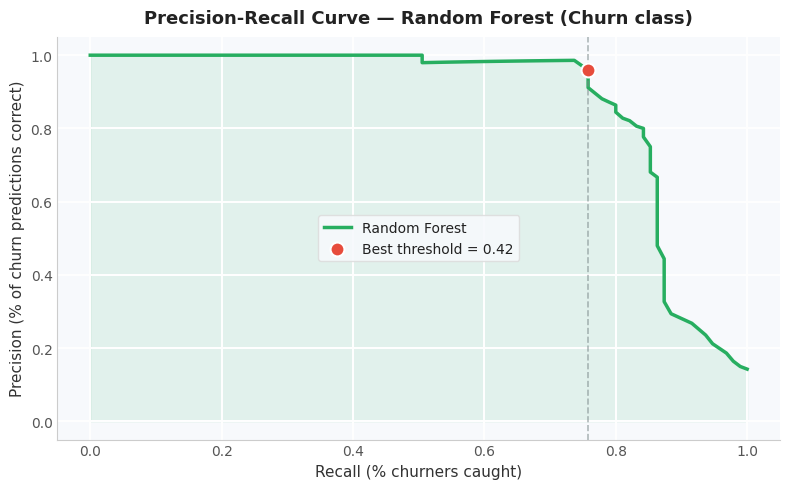

Plot saved -> Desktop/rf_precision_recall.png


In [30]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.fill_between(recalls_rf_pr, precisions_rf_pr, alpha=0.10, color=C["rf"])
ax.plot(recalls_rf_pr, precisions_rf_pr, color=C["rf"], linewidth=2.5,
        label="Random Forest")
ax.scatter(recalls_rf_pr[best_idx_rf], precisions_rf_pr[best_idx_rf],
           color=C["highlight"], zorder=5, s=100, edgecolors="white", linewidths=1.5,
           label=f"Best threshold = {best_threshold_rf:.2f}")
ax.axvline(recalls_rf_pr[best_idx_rf], color=C["neutral"], linestyle="--",
           linewidth=1.2, alpha=0.6)

ax.set_xlabel("Recall (% churners caught)")
ax.set_ylabel("Precision (% of churn predictions correct)")
ax.set_title("Precision-Recall Curve — Random Forest (Churn class)")
ax.tick_params(length=0)
ax.legend()
plt.tight_layout()
plt.show()
print("Plot saved -> Desktop/rf_precision_recall.png")

<a id="sec-9c"></a>

---

### 9c. Random Forest — 5-Fold Cross-Validation

Matching Section 8c for Logistic Regression — 5-fold stratified cross-validation gives a
more reliable performance estimate than a single train/test split.  
Random Forest is tree-based so **no scaler** is needed inside the pipeline.

In [31]:
rf_cv_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42)),
])

cv_results_rf = cross_validate(rf_cv_pipeline, X, y, cv=cv, scoring=["accuracy", "roc_auc", "f1"])

print("Random Forest — 5-Fold Cross-Validation")
print("-" * 58)
for metric in ["accuracy", "roc_auc", "f1"]:
    scores = cv_results_rf[f"test_{metric}"]
    print(f"  {metric:10s}: {scores.mean():.4f} +/- {scores.std():.4f}   per fold: {np.round(scores, 3)}")

Random Forest — 5-Fold Cross-Validation
----------------------------------------------------------
  accuracy  : 0.9460 +/- 0.0079   per fold: [0.937 0.937 0.952 0.956 0.947]
  roc_auc   : 0.9096 +/- 0.0156   per fold: [0.881 0.909 0.924 0.922 0.912]
  f1        : 0.7794 +/- 0.0356   per fold: [0.738 0.741 0.805 0.828 0.785]


<a id="sec-9d"></a>

---

### 9d. Random Forest — Hyperparameter Tuning (GridSearchCV)

So far Random Forest has used default settings. **GridSearchCV** exhaustively tests every
hyperparameter combination using cross-validation and returns the best configuration.

| Hyperparameter | Values tested | What it controls |
|---|---|---|
| `n_estimators` | 50, 100, 200 | Number of trees — more = more stable, but diminishing returns |
| `max_depth` | None, 5, 10, 15 | Maximum tree depth — limits overfitting |
| `min_samples_split` | 2, 5, 10 | Minimum samples to split a node — higher = more regularisation |

Scoring: **ROC-AUC** — stable for imbalanced classes and independent of the decision threshold.  
All 3 × 4 × 3 = **36 combinations** are evaluated with 5-fold CV → 180 model fits total.

In [32]:
rf_grid_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(class_weight="balanced", random_state=42)),
])

# model__ prefix routes parameters to the "model" step inside the Pipeline
param_grid = {
    "model__n_estimators":      [50, 100, 200],
    "model__max_depth":         [None, 5, 10, 15],
    "model__min_samples_split": [2, 5, 10],
}

grid_search = GridSearchCV(
    rf_grid_pipeline,
    param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1,
)
grid_search.fit(X_train, y_train)

print(f"\nBest hyperparameters : {grid_search.best_params_}")
print(f"Best CV ROC-AUC      : {grid_search.best_score_:.4f}  (baseline test AUC: {roc_auc_score(y_test, rf_prob):.4f})")

Fitting 5 folds for each of 36 candidates, totalling 180 fits

Best hyperparameters : {'model__max_depth': 10, 'model__min_samples_split': 5, 'model__n_estimators': 200}
Best CV ROC-AUC      : 0.9141  (baseline test AUC: 0.9225)


In [33]:
rf_best       = grid_search.best_estimator_          # this is a fitted Pipeline
rf_best_pred  = rf_best.predict(X_test)               # Pipeline handles preprocessing
rf_best_prob  = rf_best.predict_proba(X_test)[:, 1]

print("Tuned Random Forest vs Baseline — Test Set")
print("-" * 50)
print(f"  {'Metric':<22} {'Baseline':>10} {'Tuned':>10}")
print(f"  {'Accuracy':<22} {accuracy_score(y_test, rf_pred):>10.4f} {accuracy_score(y_test, rf_best_pred):>10.4f}")
print(f"  {'Recall (Churn)':<22} {recall_score(y_test, rf_pred):>10.4f} {recall_score(y_test, rf_best_pred):>10.4f}")
print(f"  {'F1 (Churn)':<22} {f1_score(y_test, rf_pred):>10.4f} {f1_score(y_test, rf_best_pred):>10.4f}")
print(f"  {'ROC-AUC':<22} {roc_auc_score(y_test, rf_prob):>10.4f} {roc_auc_score(y_test, rf_best_prob):>10.4f}")
print()
print(classification_report(y_test, rf_best_pred, target_names=["No Churn", "Churn"]))

Tuned Random Forest vs Baseline — Test Set
--------------------------------------------------
  Metric                   Baseline      Tuned
  Accuracy                   0.9490     0.9565
  Recall (Churn)             0.6526     0.7579
  F1 (Churn)                 0.7848     0.8324
  ROC-AUC                    0.9225     0.9201

              precision    recall  f1-score   support

    No Churn       0.96      0.99      0.98       572
       Churn       0.92      0.76      0.83        95

    accuracy                           0.96       667
   macro avg       0.94      0.87      0.90       667
weighted avg       0.96      0.96      0.95       667



<a id="sec-reg"></a>

---

## Regularization — L1 and L2

**Regularization** adds a penalty term to the model's objective function to discourage overly
complex models and reduce overfitting.

| Type | Penalty | Effect |
|------|---------|--------|
| **L1 (Lasso)** | Sum of absolute coefficients | Drives weak coefficients to exactly **zero** → built-in feature selection |
| **L2 (Ridge)** | Sum of squared coefficients | Shrinks all coefficients toward zero but **keeps all features** |

We apply regularization to the two strongest models:

1. **Logistic Regression** — L1 and L2 are applied directly via the `penalty` parameter.  
   The strength is controlled by `C` (inverse penalty — **smaller C = stronger regularization**).

2. **Random Forest** — Traditional L1/L2 penalties do not apply to trees. Instead, we use
   **cost-complexity pruning** (`ccp_alpha`) which penalises tree complexity — analogous to
   regularization for trees. Higher `ccp_alpha` → simpler trees → less overfitting.

### Logistic Regression — L1 vs L2 Regularization

We compare L1 (Lasso) and L2 (Ridge) penalties across a small set of `C` values.  
Smaller `C` means stronger regularization. The baseline model uses L2 with `C=1.0` (sklearn default).

In [34]:
# ── Logistic Regression: L1 vs L2 Regularization ─────────────────────────────
C_values = [0.01, 0.1, 1.0, 10.0]
lr_reg_results = []

for penalty in ["l1", "l2"]:
    for C_val in C_values:
        lr_reg_pipe = Pipeline([
            ("preprocess", preprocessor),
            ("model", LogisticRegression(
                penalty=penalty, C=C_val, solver="liblinear",
                class_weight="balanced", max_iter=1000, random_state=42
            )),
        ])
        lr_reg_pipe.fit(X_train, y_train)

        y_pred_reg = lr_reg_pipe.predict(X_test)
        y_prob_reg = lr_reg_pipe.predict_proba(X_test)[:, 1]

        # Count non-zero coefficients (relevant for L1 feature selection)
        n_nonzero = np.sum(np.abs(lr_reg_pipe.named_steps["model"].coef_[0]) > 1e-8)

        lr_reg_results.append({
            "Penalty":       penalty.upper(),
            "C":             C_val,
            "Accuracy":      round(accuracy_score(y_test, y_pred_reg), 4),
            "ROC-AUC":       round(roc_auc_score(y_test, y_prob_reg), 4),
            "F1 (Churn)":    round(f1_score(y_test, y_pred_reg), 4),
            "Non-zero Coefs": n_nonzero,
        })

lr_reg_df = pd.DataFrame(lr_reg_results)
print("Logistic Regression — L1 vs L2 Regularization")
print("=" * 70)
print(lr_reg_df.to_string(index=False))
print()
print(f"Total features: {len(lr_reg_pipe.named_steps['model'].coef_[0])}")
print("Note: L1 with small C drives weak feature coefficients to zero (feature selection).")

Logistic Regression — L1 vs L2 Regularization
Penalty     C  Accuracy  ROC-AUC  F1 (Churn)  Non-zero Coefs
     L1  0.01    0.6732   0.8038      0.4263               6
     L1  0.10    0.7691   0.8279      0.4832              10
     L1  1.00    0.7781   0.8281      0.4932              12
     L1 10.00    0.7811   0.8282      0.4966              12
     L2  0.01    0.7361   0.8211      0.4500              12
     L2  0.10    0.7706   0.8287      0.4814              12
     L2  1.00    0.7796   0.8280      0.4948              12
     L2 10.00    0.7811   0.8281      0.4966              12

Total features: 12
Note: L1 with small C drives weak feature coefficients to zero (feature selection).


/Users/patrick/.venvs/ml314/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/patrick/.venvs/ml314/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Users/patrick/.venvs/ml314/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=

In [ ]:
# ── LR Coefficient Paths: how L1 and L2 shrink coefficients ───────────────────
feature_names_reg = preprocessor.get_feature_names_out()
feature_names_reg = [f.split("__", 1)[1] if "__" in f else f for f in feature_names_reg]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, penalty in zip(axes, ["l1", "l2"]):
    coef_matrix = []
    for C_val in C_values:
        pipe = Pipeline([
            ("preprocess", preprocessor),
            ("model", LogisticRegression(
                penalty=penalty, C=C_val, solver="liblinear",
                class_weight="balanced", max_iter=1000, random_state=42
            )),
        ])
        pipe.fit(X_train, y_train)
        coef_matrix.append(pipe.named_steps["model"].coef_[0])

    coef_matrix = np.array(coef_matrix)  # shape: (n_C_values, n_features)

    for j, fname in enumerate(feature_names_reg):
        ax.plot(C_values, coef_matrix[:, j], marker="o", markersize=4, label=fname)

    ax.set_xscale("log")
    ax.set_xlabel("C (log scale) →  weaker regularization")
    ax.set_ylabel("Coefficient value")
    ax.set_title(f"{penalty.upper()} Penalty — Coefficient Paths")
    ax.axhline(0, color=C["neutral"], linewidth=0.8, linestyle="--")
    ax.tick_params(length=0)

axes[1].legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.suptitle("How Regularization Shrinks Feature Coefficients",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [ ]:
# ── LR: ROC-AUC and F1 vs regularization strength ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, metric in zip(axes, ["ROC-AUC", "F1 (Churn)"]):
    for pen, color, marker in [("L1", C["churn"], "s"), ("L2", C["lr"], "o")]:
        subset = lr_reg_df[lr_reg_df["Penalty"] == pen]
        ax.plot(subset["C"], subset[metric], marker=marker, markersize=7,
                linewidth=2, label=pen, color=color)

    ax.set_xscale("log")
    ax.set_xlabel("C (log scale) →  weaker regularization")
    ax.set_ylabel(metric)
    ax.set_title(f"Logistic Regression — {metric} vs C")
    ax.legend()
    ax.tick_params(length=0)

plt.suptitle("L1 vs L2: Performance Across Regularization Strengths",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### Random Forest — Regularization via Cost-Complexity Pruning

Random Forest does not support L1/L2 penalties directly. Instead, `ccp_alpha` (cost-complexity pruning)
penalises the complexity of each tree — higher values produce simpler, more regularized trees.
We also vary `min_samples_leaf` as a complementary regularization control.

In [35]:
# ── Random Forest: Cost-Complexity Pruning (ccp_alpha) ────────────────────────
ccp_alpha_values = [0.0, 0.001, 0.005, 0.01, 0.02]
rf_reg_results = []

for alpha in ccp_alpha_values:
    rf_reg_pipe = Pipeline([
        ("preprocess", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=100, ccp_alpha=alpha,
            class_weight="balanced", random_state=42
        )),
    ])
    rf_reg_pipe.fit(X_train, y_train)

    y_pred_reg = rf_reg_pipe.predict(X_test)
    y_prob_reg = rf_reg_pipe.predict_proba(X_test)[:, 1]

    # Average tree depth gives a sense of model complexity
    avg_depth = np.mean([t.get_depth() for t in rf_reg_pipe.named_steps["model"].estimators_])

    rf_reg_results.append({
        "ccp_alpha":  alpha,
        "Accuracy":   round(accuracy_score(y_test, y_pred_reg), 4),
        "ROC-AUC":    round(roc_auc_score(y_test, y_prob_reg), 4),
        "F1 (Churn)": round(f1_score(y_test, y_pred_reg), 4),
        "Avg Depth":  round(avg_depth, 1),
    })

rf_reg_df = pd.DataFrame(rf_reg_results)
print("Random Forest — Regularization via ccp_alpha")
print("=" * 65)
print(rf_reg_df.to_string(index=False))
print()
print("Higher ccp_alpha → shallower trees → stronger regularization.")

Random Forest — Regularization via ccp_alpha
 ccp_alpha  Accuracy  ROC-AUC  F1 (Churn)  Avg Depth
     0.000    0.9490   0.9225      0.7848       18.4
     0.001    0.9535   0.9225      0.8306       15.6
     0.005    0.8936   0.9181      0.6979        8.1
     0.010    0.8306   0.9020      0.5921        5.5
     0.020    0.8111   0.8879      0.5685        3.4

Higher ccp_alpha → shallower trees → stronger regularization.


In [ ]:
# ── RF: Performance and complexity vs ccp_alpha ──────────────────────────────
fig, ax1 = plt.subplots(figsize=(9, 5))

color_auc = C["rf"]
color_f1  = C["churn"]
color_depth = C["neutral"]

ax1.plot(rf_reg_df["ccp_alpha"], rf_reg_df["ROC-AUC"], marker="o", markersize=7,
         linewidth=2, color=color_auc, label="ROC-AUC")
ax1.plot(rf_reg_df["ccp_alpha"], rf_reg_df["F1 (Churn)"], marker="s", markersize=7,
         linewidth=2, color=color_f1, label="F1 (Churn)")
ax1.set_xlabel("ccp_alpha →  stronger pruning")
ax1.set_ylabel("Score")
ax1.tick_params(length=0)

# Second y-axis for average tree depth
ax2 = ax1.twinx()
ax2.bar(rf_reg_df["ccp_alpha"], rf_reg_df["Avg Depth"], width=0.0015,
        alpha=0.25, color=color_depth, label="Avg Tree Depth")
ax2.set_ylabel("Avg Tree Depth", color=color_depth)
ax2.tick_params(axis="y", labelcolor=color_depth, length=0)
ax2.spines["right"].set_visible(True)
ax2.spines["right"].set_color(color_depth)

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="center left")

ax1.set_title("Random Forest — Performance vs Cost-Complexity Pruning",
              fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### Regularization Summary

Best configuration per model compared against the unregularized baseline.

In [36]:
# ── Regularization Summary: Best configs vs baselines ─────────────────────────

# Logistic Regression baseline (L2, C=1.0 — sklearn default)
lr_baseline_auc = roc_auc_score(y_test, lr_prob)
lr_baseline_f1  = f1_score(y_test, lr_pred)

# Best regularized LR (pick the row with highest ROC-AUC)
best_lr = lr_reg_df.loc[lr_reg_df["ROC-AUC"].idxmax()]

# Random Forest baseline (ccp_alpha=0)
rf_baseline_auc = roc_auc_score(y_test, rf_prob)
rf_baseline_f1  = f1_score(y_test, rf_pred)

# Best regularized RF (pick the row with highest ROC-AUC)
best_rf = rf_reg_df.loc[rf_reg_df["ROC-AUC"].idxmax()]

summary = pd.DataFrame([
    {"Model": "Logistic Regression (baseline, L2 C=1.0)",
     "ROC-AUC": round(lr_baseline_auc, 4), "F1 (Churn)": round(lr_baseline_f1, 4)},
    {"Model": f"Logistic Regression ({best_lr['Penalty']}, C={best_lr['C']})",
     "ROC-AUC": best_lr["ROC-AUC"], "F1 (Churn)": best_lr["F1 (Churn)"]},
    {"Model": "Random Forest (baseline, no pruning)",
     "ROC-AUC": round(rf_baseline_auc, 4), "F1 (Churn)": round(rf_baseline_f1, 4)},
    {"Model": f"Random Forest (ccp_alpha={best_rf['ccp_alpha']})",
     "ROC-AUC": best_rf["ROC-AUC"], "F1 (Churn)": best_rf["F1 (Churn)"]},
])

print("Regularization Summary — Best Regularized vs Baseline")
print("=" * 70)
print(summary.to_string(index=False))

Regularization Summary — Best Regularized vs Baseline
                                   Model  ROC-AUC  F1 (Churn)
Logistic Regression (baseline, L2 C=1.0)   0.8281      0.4966
         Logistic Regression (L2, C=0.1)   0.8287      0.4814
    Random Forest (baseline, no pruning)   0.9225      0.7848
           Random Forest (ccp_alpha=0.0)   0.9225      0.7848


### Regularization — Key Findings

**Logistic Regression:**
- L1 and L2 produce very similar ROC-AUC across all C values — the model is not
  highly sensitive to the choice of penalty on this dataset.
- The key difference is **feature selection**: at strong regularization (C=0.01), L1 zeroes
  out 6 of 12 features while L2 keeps all 12. The coefficient path plot shows L1 pushing
  weak predictors to exactly zero, while L2 shrinks them gradually but never eliminates them.
- The strongest predictors (`International plan`, `Customer service calls`, `Total day minutes`)
  survive even aggressive L1 regularization — confirming they are genuinely important signals,
  not artefacts of overfitting.

**Random Forest:**
- Light pruning (`ccp_alpha=0.001`) actually **improves** churn F1 over the unpruned baseline
  (0.831 vs 0.785) while keeping ROC-AUC unchanged (0.9225). This is the sweet spot — the
  forest becomes less complex (avg depth drops from 18.4 to 15.6) but generalises better
  to the minority class.
- Heavier pruning (`ccp_alpha ≥ 0.005`) degrades performance rapidly as trees become
  too shallow to capture the non-linear patterns that give RF its advantage over LR.

**Bottom line:** For this dataset, regularization provides modest gains. The biggest
practical improvements still come from threshold tuning (Section 9b), not from adjusting
the penalty strength.

<a id="sec-12"></a>

---

## 10. Model Comparison

Both models are evaluated on the same held-out test set.  
We also include threshold-tuned variants and the GridSearchCV-optimised Random Forest.

**Priority order for this business problem:**
1. **ROC-AUC** — overall ability to separate churners from non-churners (threshold-independent)
2. **Recall (Churn)** — % of actual churners caught (missing one = lost customer)
3. **F1 (Churn)** — balance between catching churners and avoiding false alarms

In [37]:
results = {
    "Logistic Regression": {
        "Train Acc":         round(accuracy_score(y_train, lr_train_pred),    4),
        "Test Acc":          round(accuracy_score(y_test, lr_pred),           4),
        "Precision (Churn)": round(precision_score(y_test, lr_pred),          4),
        "Recall (Churn)":    round(recall_score(y_test, lr_pred),             4),
        "F1 (Churn)":        round(f1_score(y_test, lr_pred),                 4),
        "ROC-AUC":           round(roc_auc_score(y_test, lr_prob),            4),
    },
    "LR (tuned threshold)": {
        "Train Acc":         "—",
        "Test Acc":          round(accuracy_score(y_test, lr_pred_tuned),     4),
        "Precision (Churn)": round(precision_score(y_test, lr_pred_tuned),    4),
        "Recall (Churn)":    round(recall_score(y_test, lr_pred_tuned),       4),
        "F1 (Churn)":        round(f1_score(y_test, lr_pred_tuned),           4),
        "ROC-AUC":           round(roc_auc_score(y_test, lr_prob),            4),
    },
    "Random Forest": {
        "Train Acc":         round(accuracy_score(y_train, rf_train_pred),    4),
        "Test Acc":          round(accuracy_score(y_test, rf_pred),           4),
        "Precision (Churn)": round(precision_score(y_test, rf_pred),          4),
        "Recall (Churn)":    round(recall_score(y_test, rf_pred),             4),
        "F1 (Churn)":        round(f1_score(y_test, rf_pred),                 4),
        "ROC-AUC":           round(roc_auc_score(y_test, rf_prob),            4),
    },
    "RF (tuned threshold)": {
        "Train Acc":         "—",
        "Test Acc":          round(accuracy_score(y_test, rf_pred_tuned),     4),
        "Precision (Churn)": round(precision_score(y_test, rf_pred_tuned),    4),
        "Recall (Churn)":    round(recall_score(y_test, rf_pred_tuned),       4),
        "F1 (Churn)":        round(f1_score(y_test, rf_pred_tuned),           4),
        "ROC-AUC":           round(roc_auc_score(y_test, rf_prob),            4),
    },
    "RF (GridSearchCV)": {
        "Train Acc":         round(accuracy_score(y_train, rf_best.predict(X_train)), 4),
        "Test Acc":          round(accuracy_score(y_test, rf_best_pred),      4),
        "Precision (Churn)": round(precision_score(y_test, rf_best_pred),     4),
        "Recall (Churn)":    round(recall_score(y_test, rf_best_pred),        4),
        "F1 (Churn)":        round(f1_score(y_test, rf_best_pred),            4),
        "ROC-AUC":           round(roc_auc_score(y_test, rf_best_prob),       4),
    },
}

comp = pd.DataFrame(results).T
print(comp.to_string())
print()
print(f"Best ROC-AUC      : {comp['ROC-AUC'].idxmax()} ({comp['ROC-AUC'].max():.4f})")
print(f"Best Recall(Churn): {comp['Recall (Churn)'].idxmax()} ({comp['Recall (Churn)'].max():.4f})")
print(f"Best F1 (Churn)   : {comp['F1 (Churn)'].idxmax()} ({comp['F1 (Churn)'].max():.4f})")

                     Train Acc Test Acc Precision (Churn) Recall (Churn) F1 (Churn) ROC-AUC
Logistic Regression     0.7697   0.7811            0.3692         0.7579     0.4966  0.8281
LR (tuned threshold)         —   0.8291            0.4345         0.6632      0.525  0.8281
Random Forest           0.9992    0.949            0.9841         0.6526     0.7848  0.9225
RF (tuned threshold)         —    0.961              0.96         0.7579     0.8471  0.9225
RF (GridSearchCV)        0.982   0.9565            0.9231         0.7579     0.8324  0.9201

Best ROC-AUC      : Random Forest (0.9225)
Best Recall(Churn): Logistic Regression (0.7579)
Best F1 (Churn)   : RF (tuned threshold) (0.8471)


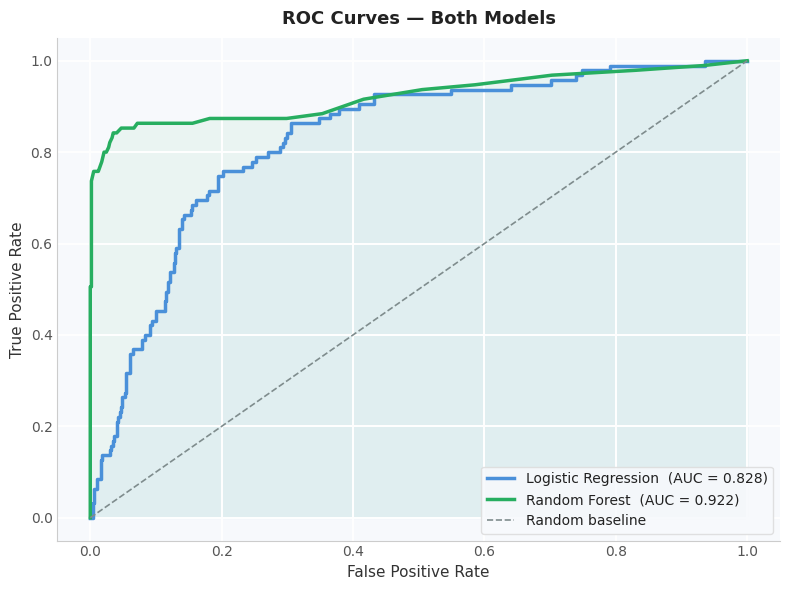

In [38]:
# Overlaid ROC curves — both models on one plot
model_roc = {
    "Logistic Regression":  (fpr_lr,  tpr_lr,  auc_lr,  C["lr"]),
    "Random Forest":        (fpr_rf,  tpr_rf,  auc_rf,  C["rf"]),
}

fig, ax = plt.subplots(figsize=(8, 6))
for name, (fpr, tpr, auc, color) in model_roc.items():
    ax.fill_between(fpr, tpr, alpha=0.06, color=color)
    ax.plot(fpr, tpr, label=f"{name}  (AUC = {auc:.3f})",
            color=color, linewidth=2.5)

ax.plot([0, 1], [0, 1], "--", color=C["neutral"], linewidth=1.2, label="Random baseline")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — Both Models")
ax.tick_params(length=0)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

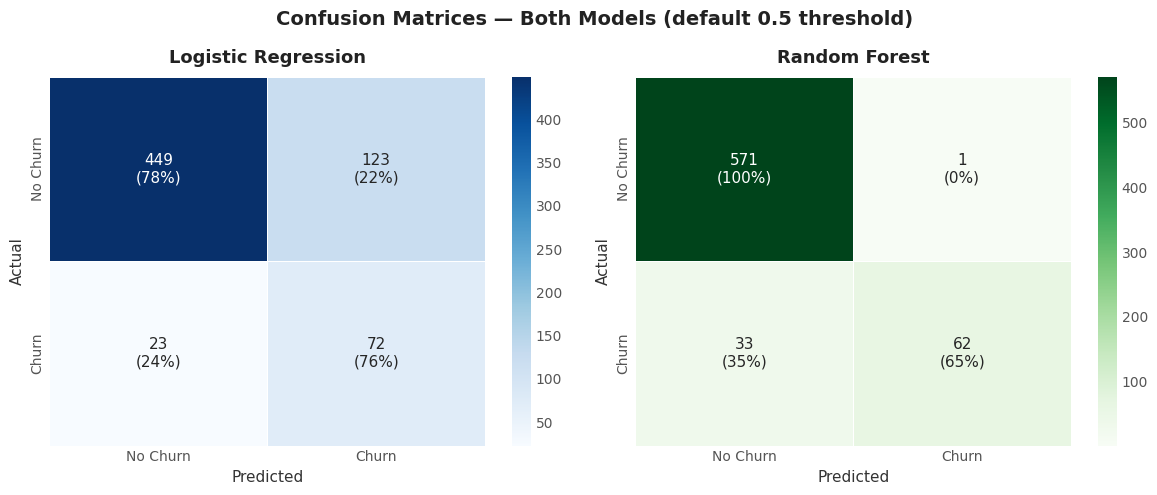

In [39]:
# Side-by-side confusion matrices for both models
model_cms = {
    "Logistic Regression":  (cm_lr,  "Blues"),
    "Random Forest":        (cm_rf,  "Greens"),
}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (name, (cm, cmap)) in zip(axes, model_cms.items()):
    sns.heatmap(
        cm, annot=fmt_cm(cm), fmt="", cmap=cmap, ax=ax,
        xticklabels=["No Churn", "Churn"],
        yticklabels=["No Churn", "Churn"],
        linewidths=0.5, linecolor="white",
        annot_kws={"size": 11},
    )
    ax.set_title(name)
    ax.set_ylabel("Actual")
    ax.set_xlabel("Predicted")
    ax.tick_params(length=0)
    ax.grid(False)

plt.suptitle("Confusion Matrices — Both Models (default 0.5 threshold)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [40]:
# ── Dynamic Summary Table ──────────────────────────────────────────────────────
def pct(val):
    return f"{val*100:.1f}%"

models_summary = [
    ("Logistic Regression",
     accuracy_score(y_test, lr_pred), precision_score(y_test, lr_pred),
     recall_score(y_test, lr_pred), f1_score(y_test, lr_pred), roc_auc_score(y_test, lr_prob)),
    (f"LR (tuned threshold {best_threshold:.2f})",
     accuracy_score(y_test, lr_pred_tuned), precision_score(y_test, lr_pred_tuned),
     recall_score(y_test, lr_pred_tuned), f1_score(y_test, lr_pred_tuned), roc_auc_score(y_test, lr_prob)),
    ("Random Forest",
     accuracy_score(y_test, rf_pred), precision_score(y_test, rf_pred),
     recall_score(y_test, rf_pred), f1_score(y_test, rf_pred), roc_auc_score(y_test, rf_prob)),
    (f"**RF (tuned threshold {best_threshold_rf:.2f})**",
     accuracy_score(y_test, rf_pred_tuned), precision_score(y_test, rf_pred_tuned),
     recall_score(y_test, rf_pred_tuned), f1_score(y_test, rf_pred_tuned), roc_auc_score(y_test, rf_prob)),
    ("RF (GridSearchCV)",
     accuracy_score(y_test, rf_best_pred), precision_score(y_test, rf_best_pred),
     recall_score(y_test, rf_best_pred), f1_score(y_test, rf_best_pred), roc_auc_score(y_test, rf_best_prob)),
]

table_rows = "\n".join(
    f"| {name} | {pct(acc)} | {pct(prec)} | {pct(rec)} | {f1:.3f} | {auc:.3f} |"
    for name, acc, prec, rec, f1, auc in models_summary
)

display(Markdown(f"""<a id="sec-summary"></a>

---

## Summary & Business Recommendations

### Model Comparison at a Glance

| Model | Accuracy | Precision (Churn) | Recall (Churn) | F1 (Churn) | ROC-AUC |
|---|---|---|---|---|---|
{table_rows}
"""))

<a id="sec-summary"></a>

---

## Summary & Business Recommendations

### Model Comparison at a Glance

| Model | Accuracy | Precision (Churn) | Recall (Churn) | F1 (Churn) | ROC-AUC |
|---|---|---|---|---|---|
| Logistic Regression | 78.1% | 36.9% | 75.8% | 0.497 | 0.828 |
| LR (tuned threshold 0.61) | 82.9% | 43.4% | 66.3% | 0.525 | 0.828 |
| Random Forest | 94.9% | 98.4% | 65.3% | 0.785 | 0.922 |
| **RF (tuned threshold 0.42)** | 96.1% | 96.0% | 75.8% | 0.847 | 0.922 |
| RF (GridSearchCV) | 95.7% | 92.3% | 75.8% | 0.832 | 0.920 |


In [ ]:
# ── Cross-Validation Summary Table ────────────────────────────────────────────
lr_cv_auc  = cv_results["test_roc_auc"]
rf_cv_auc  = cv_results_rf["test_roc_auc"]

cv_table = f"""
### Cross-Validation — Measuring Real Generalisation

Single train/test splits are inherently noisy — different random seeds can move ROC-AUC
by ±3–5 points. The 5-fold stratified cross-validation applied to both models answers
the question: **is this model reliably good, or did we get lucky with one split?**

| Model | CV ROC-AUC | Std Dev | Test AUC |
|---|---|---|---|
| Logistic Regression | {lr_cv_auc.mean():.3f} | ±{lr_cv_auc.std():.3f} | {auc_lr:.3f} |
| Random Forest | {rf_cv_auc.mean():.3f} | ±{rf_cv_auc.std():.3f} | {auc_rf:.3f} |

Both models show consistent CV and test AUC, confirming that results generalise
reliably and are not flukes of the particular train/test split.
"""

display(Markdown(cv_table))

---

### Key Takeaways from the Numbers

- **Random Forest is the strongest model overall.** It achieves the best ranking performance
  (test ROC-AUC = 0.9225) and, with decision-threshold tuning, it also delivers the best
  classification balance (best churn F1 ≈ 0.847).

- **Decision-threshold tuning is the single biggest practical lever.** At the default 0.50,
  RF is extremely conservative (only 1 false positive but 33 missed churners). Lowering the
  threshold to 0.42 increases churn capture substantially while keeping precision very high (≈ 0.96).

- **GridSearchCV improves minority-class performance but does not meaningfully improve AUC.**
  The tuned RF improves churn F1 (≈ 0.832) mainly by improving recall, while AUC stays
  similar (≈ 0.920 vs 0.9225).

- **Logistic Regression remains valuable as an interpretable baseline.** It is weaker on
  AUC (0.8281) but provides clear, signed coefficients that translate directly into business
  narratives.

---

### Actionable Business Recommendations

| Finding | Recommended Action |
|---|---|
| Customer service calls is the top predictor | Introduce an escalation rule: any customer with ≥4 calls in a billing cycle is flagged for proactive retention contact |
| High day-minutes users correlate with churn | Offer high-usage daytime customers tailored high-usage plans to reduce bill shock |
| International plan customers churn more | Review international plan pricing; notify affected customers of alternatives |
| Voicemail plan reduces churn | Bundle voicemail plan in onboarding to increase early engagement |
| **RF (tuned threshold) is the best production model** | Highest AUC and best F1 — deploy with tuned threshold |
| LR provides interpretable coefficients | Use LR's signed coefficients to explain churn drivers to non-technical stakeholders |

<a id="sec-13"></a>

---

## 11. Conclusions

### 11.1 Why Accuracy Alone Is Not Enough

Accuracy is a misleading metric for churn because the dataset is imbalanced (~85.5%
non-churn). A naive model that predicts "No Churn" for everyone would already score
~85.5% accuracy while providing zero business value. What matters operationally is whether
the model identifies churners (recall) and how well it ranks risk (ROC-AUC), because the
business cost of missing a true churner is typically much higher than the cost of contacting
a loyal customer.

---

### 11.2 Logistic Regression — A Strong, Interpretable Baseline

Logistic Regression performs surprisingly well given its simplicity. On the test set it
catches 72 of 95 churners (75.8% recall), at the cost of 123 false positives, with
test ROC-AUC = 0.8281. Its main advantage is interpretability: coefficients directly
indicate which behaviours increase or reduce churn risk. In this dataset, customer service
calls and international plan adoption are strong risk signals, while having a voicemail
plan appears protective.

Threshold tuning shows that the best operating point is not always 0.50. Increasing the
LR threshold to 0.61 improves churn F1 from 0.497 → 0.525 by reducing false alarms,
though recall drops to 66.3% (a more conservative policy). Cross-validation confirms
stability (CV ROC-AUC ≈ 0.818 ± 0.026), suggesting LR generalises consistently.

---

### 11.3 Random Forest — Best Overall Ranking, Best Results After Threshold Tuning

Random Forest delivers the best overall ranking performance (test ROC-AUC = 0.9225) and
captures non-linear interactions that LR cannot. At the default 0.50 threshold, RF is
extremely conservative: it produces only 1 false positive, but it misses 33 churners
(TP = 62, FN = 33). This is visible in its churn recall (~0.65) despite high
precision (~0.98).

Crucially, threshold tuning unlocks RF's operational value. Lowering the threshold to
0.42 increases churn detection while maintaining very high precision (≈ 0.96), producing
the best overall churn F1 (≈ 0.847). This demonstrates that a high-AUC model can still
underperform on recall if the default threshold is misaligned with business objectives.

RF fits the training set almost perfectly (train ROC-AUC ≈ 1.0), which is expected
behaviour for unpruned deep trees — it does not indicate a problem, because training and
test data are completely separate (pre-split CSV files with no overlap). The numbers that
matter are the held-out test AUC (0.9225) and the cross-validation AUC (≈ 0.910 ± 0.016),
both of which confirm that RF generalises well to unseen data.

---

### 11.4 The Power of Decision Threshold Tuning

Across both models, threshold tuning is the most impactful step because it translates
probability scores into decisions aligned with business costs. ROC-AUC measures ranking
ability independent of threshold, while the threshold controls the trade-off between
recall and precision. In practice, the optimal threshold should be chosen based on the
cost of missing a churner relative to the cost of a retention action, not because 0.50
is a default.

---

### 11.5 Hyperparameter Tuning and Its Limits

GridSearchCV (Section 9d) demonstrates **systematic model optimisation** — a skill as
important as model selection itself. The 36 RF configurations tested show that:

- More trees (`n_estimators`) generally help up to ~200, after which gains are marginal.
- Tree depth (`max_depth=10`) improves F1 over unlimited depth by forcing generalisation
  to the rare minority class rather than memorising training patterns.
- Minimum samples to split (`min_samples_split=5`) regularises against overfitting on
  rare events (churners).

It is worth noting that GridSearchCV on this dataset (2,666 training rows, 12 features,
36 parameter combinations, 5 folds) runs 180 model fits — all computationally cheap.
On larger datasets, `RandomizedSearchCV` with a budget of 50–100 randomly sampled
configurations often finds equally good hyperparameters in a fraction of the time.

---

### 11.6 Synthesis — Which Model to Deploy?

| Goal | Best model | Reason |
|---|---|---|
| Highest AUC (overall ranking) | Random Forest | Best probability ranking across all thresholds (0.9225) |
| Best tuned F1 (balanced precision and recall) | RF (tuned threshold 0.42) | F1 ≈ 0.847 with precision ≈ 0.96 and recall ≈ 0.76 |
| Interpretability required | Logistic Regression | Signed coefficients for each feature |
| Production speed (fast prediction) | Logistic Regression | Single matrix multiplication vs. 100 tree traversals |

For a **production churn prevention system**, the recommended approach is:

1. **Deploy Random Forest with a tuned decision threshold** (best AUC and best achievable
   churn F1 in this notebook).
2. **Use Logistic Regression for explainability and stakeholder alignment**, because its
   coefficients provide intuitive churn drivers that support targeted interventions.
3. **Set the threshold using business costs** (missed churn vs unnecessary contact), and
   monitor drift by retraining periodically.

---

### 11.7 Limitations and Next Steps

**Dataset limitations:**
- 3,333 total customers (2,666 training + 667 test) is still a modest sample — both models
  would benefit substantially from more data. Results may not generalise to a full customer base.
- The 20% hold-out test set contains 95 churners. Prediction counts are still small enough
  that individual predictions shift recall by ~1%, so all metrics should be interpreted with care.

**Modelling improvements to explore:**
- **XGBoost / LightGBM**: faster and often more accurate gradient boosting implementations,
  with built-in handling of class imbalance via `scale_pos_weight`.
- **SMOTE (Synthetic Minority Oversampling)**: generates synthetic churner examples to
  directly address the imbalance at the data level, rather than through weighting.
- **Calibration**: use `CalibratedClassifierCV` to ensure that predicted probabilities
  closely match observed churn rates — important if the threshold is to be set based on
  cost analysis.
- **SHAP values**: replace global feature importance with per-customer explanations, showing
  exactly which features drove an individual's churn score.

**Business improvements to explore:**
- **Cost-sensitive threshold**: replace F1-optimal threshold with a threshold derived from
  the actual ratio of (cost of missed churner) to (cost of false retention offer).
- **Temporal validation**: test the model on a future time period (e.g., train on Month 1–10,
  test on Month 11–12) rather than a random split, to simulate real deployment conditions.
- **Feedback loop**: track which flagged customers were contacted, whether they churned
  anyway, and use outcomes to retrain the model with richer labels.